# Training NPZ Time-Series Analysis

Load the exported training `.npz` files, compute the autonomous Vivana-TD rollout from the ground-truth initial condition, and plot time-domain displacement, force per unit length, and integrator-check displacement error views for each case.


In [43]:
from __future__ import annotations

import math
import os
import sys
from pathlib import Path

PLOT_CACHE_DIR = Path.cwd() / ".plot_cache"
MPLCONFIGDIR = PLOT_CACHE_DIR / "matplotlib"
XDG_CACHE_HOME = PLOT_CACHE_DIR / "xdg"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
XDG_CACHE_HOME.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))
os.environ.setdefault("XDG_CACHE_HOME", str(XDG_CACHE_HOME))

import matplotlib
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import scipy.signal as signal
import numpy as np

for style_name in ("seaborn-v0_8-whitegrid", "seaborn-whitegrid", "default"):
    if style_name == "default" or style_name in plt.style.available:
        plt.style.use(style_name)
        break

In [44]:
CWD = Path.cwd().resolve()
DATASET_CANDIDATES = [
    CWD / "vivana_cfd_data_pipeline" / "npz_exports_td_burnin_trimmed",
    CWD / "npz_exports_td_burnin_trimmed",
    CWD.parent / "vivana_cfd_data_pipeline" / "npz_exports_td_burnin_trimmed",
    CWD / "vivana_cfd_data_pipeline" / "npz_exports",
    CWD / "npz_exports",
    CWD.parent / "vivana_cfd_data_pipeline" / "npz_exports",
]
DATASET_ROOT = next((path for path in DATASET_CANDIDATES if path.exists()), None)
if DATASET_ROOT is None:
    tried = "\n".join(str(path) for path in DATASET_CANDIDATES)
    raise FileNotFoundError(f"Could not locate dataset root. Tried:\n{tried}")

REPO_ROOT_CANDIDATES = [
    DATASET_ROOT.parent.parent,
    CWD,
    CWD.parent,
]
REPO_ROOT = next((path.resolve() for path in REPO_ROOT_CANDIDATES if (path / "training/training_utils.py").exists()), None)
if REPO_ROOT is None:
    tried = "\n".join(str(path) for path in REPO_ROOT_CANDIDATES)
    raise FileNotFoundError(f"Could not locate repo root. Tried:\n{tried}")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

ORDERED_SPLIT_DIRS = ("train", "val")
MAX_FILES_PER_SPLIT = None  # Set to an int to limit plots per split.
FIGSIZE = (14, 8)
TD_MASS_SOURCE = "dry"  # dry | effective
TD_PARAM_OVERRIDES = {}
NEWMARK_BETA = 0.25
NEWMARK_GAMMA = 0.5
WILSON_THETA = 1.4
DOWNSAMPLING_FACTORS = (1, 2, 5, 10, 20, 40)
CFD_FORCE_TOTAL_SCALE = 4.0  # Multiply CFD/TD per-meter forces by this factor to form total force.
FORCED_TRUTH_DAMPING_C_OVERRIDE = 1.0e-4  # Set to None to use only the stored damping.
TD_DEFAULT_PARAMS = {
    "Cv": 1.03,
    "Cd": 1.02,
    "Ca": 1.95,
    "fhat_min": 0.142,
    "fhat0": 0.142,
    "fhat_max": 0.173,
    "n_memory": 500.0,
}



In [45]:
from __future__ import annotations

def _pick_first(data, keys):
    for key in keys:
        if key in data:
            return np.asarray(data[key])
    raise KeyError(f"None of the keys were found: {keys}")


def _pick_scalar(data, keys) -> float:
    arr = np.asarray(_pick_first(data, keys), dtype=float).reshape(-1)
    if arr.size != 1:
        raise ValueError(f"Expected one scalar for keys {keys}, got shape {arr.shape}.")
    value = float(arr[0])
    if not np.isfinite(value):
        raise ValueError(f"Expected finite scalar for keys {keys}, got {value}.")
    return value


def _pick_vector(data, keys, *, n_expected: int | None = None) -> np.ndarray:
    arr = np.asarray(_pick_first(data, keys), dtype=float).reshape(-1)
    if n_expected is not None and arr.size not in {1, n_expected}:
        raise ValueError(f"Expected scalar or length {n_expected} for keys {keys}, got length {arr.size}.")
    if n_expected is not None and arr.size == 1:
        arr = np.full((n_expected,), float(arr[0]), dtype=float)
    return arr


def _pick_ur_value(data) -> float:
    for key in ("U_r_label_scalar", "label_ur", "U_r_label_series", "U_r_computed_series", "U_r"):
        if key in data:
            arr = np.asarray(data[key], dtype=float).reshape(-1)
            finite = arr[np.isfinite(arr)]
            if finite.size:
                return float(finite[0])
    return float("nan")


def _compute_effective_ur(flow_speed: np.ndarray, *, stiffness: float, effective_mass: float, diameter: float) -> float:
    flow_speed = np.asarray(flow_speed, dtype=float).reshape(-1)
    finite_speed = flow_speed[np.isfinite(flow_speed)]
    if finite_speed.size == 0:
        return float('nan')
    if not (np.isfinite(stiffness) and stiffness > 0.0 and np.isfinite(effective_mass) and effective_mass > 0.0 and np.isfinite(diameter) and diameter > 0.0):
        return float('nan')
    natural_frequency_hz = float(np.sqrt(stiffness / effective_mass) / (2.0 * np.pi))
    if not np.isfinite(natural_frequency_hz) or natural_frequency_hz <= 0.0:
        return float('nan')
    reference_speed = float(np.median(finite_speed))
    return float(reference_speed / (natural_frequency_hz * diameter))


def load_series(npz_path: Path) -> dict:
    with np.load(npz_path, allow_pickle=False) as data:
        time = np.asarray(_pick_first(data, ["time_dim", "time", "a"]), dtype=float).reshape(-1)
        displacement = np.asarray(_pick_first(data, ["y_disp_dim", "y", "x_disp_dim"]), dtype=float).reshape(-1)
        velocity = np.asarray(_pick_first(data, ["y_vel_dim", "dy", "v"]), dtype=float).reshape(-1)
        acceleration = np.asarray(_pick_first(data, ["y_acc_dim", "ddy"]), dtype=float).reshape(-1)
        span = float(CFD_FORCE_TOTAL_SCALE)
        if "y_force_dim" in data.files:
            force_total = np.asarray(data["y_force_dim"], dtype=float).reshape(-1)
        elif "x_force_dim" in data.files:
            force_total = np.asarray(data["x_force_dim"], dtype=float).reshape(-1)
        elif "y_force_per_m_dim" in data.files:
            force_total = np.asarray(data["y_force_per_m_dim"], dtype=float).reshape(-1) * span
        elif "x_force_per_m_dim" in data.files:
            force_total = np.asarray(data["x_force_per_m_dim"], dtype=float).reshape(-1) * span
        elif "force_per_m_dim" in data.files:
            force_total = np.asarray(data["force_per_m_dim"], dtype=float).reshape(-1) * span
        elif "F_total" in data.files:
            force_total = np.asarray(data["F_total"], dtype=float).reshape(-1)
        elif "cf_force" in data.files:
            force_total = np.asarray(data["cf_force"], dtype=float).reshape(-1)
        elif "y_force_nd" in data.files:
            force_total = np.asarray(data["y_force_nd"], dtype=float).reshape(-1)
        elif "x_force_nd" in data.files:
            force_total = np.asarray(data["x_force_nd"], dtype=float).reshape(-1)
        else:
            force_total = np.asarray(_pick_first(data, ["F_total"]), dtype=float).reshape(-1)
        if "y_force_per_m_dim" in data.files:
            force_per_m = np.asarray(data["y_force_per_m_dim"], dtype=float).reshape(-1)
        elif "x_force_per_m_dim" in data.files:
            force_per_m = np.asarray(data["x_force_per_m_dim"], dtype=float).reshape(-1)
        else:
            force_per_m = force_total / span
        td_force_keys = ["F_total_td_per_m", "Fy_td_per_m", "force_td_per_m", "F_total_td", "Fy_td", "force_td"]
        if any(key in data.files for key in td_force_keys):
            force_td_stored = np.asarray(_pick_first(data, td_force_keys), dtype=float).reshape(-1)
            if force_td_stored.size == time.size and not str(next(key for key in td_force_keys if key in data.files)).endswith("_per_m"):
                force_td_stored = force_td_stored / span
        else:
            force_td_stored = np.zeros_like(force_per_m)
        phi_td = np.asarray(_pick_first(data, ["phi_vy_td"]), dtype=float).reshape(-1)
        sig_dy_td = np.asarray(_pick_first(data, ["sig_dy_loc_td"]), dtype=float).reshape(-1)
        sig_ddy_td = np.asarray(_pick_first(data, ["sig_ddy_loc_td"]), dtype=float).reshape(-1)
        flow_speed = _pick_vector(data, ["flow_speed_m_s"], n_expected=time.size)
        rho = _pick_scalar(data, ["rho_kg_m3"])
        diameter = _pick_scalar(data, ["diameter_m"])
        stiffness = _pick_scalar(data, ["stiffness_n_m"])
        effective_mass = _pick_scalar(data, ["effective_mass_kg"])
        dry_mass = _pick_scalar(data, ["dry_mass_kg"])
        damping = _pick_scalar(data, ["damping_c"])
        ur = _pick_ur_value(data)

    n = time.size
    expected = [displacement, velocity, acceleration, force_total, force_per_m, force_td_stored, phi_td, sig_dy_td, sig_ddy_td, flow_speed]
    if any(arr.size != n for arr in expected):
        raise ValueError(f"{npz_path} has mismatched time-aligned array lengths.")
    if n < 2:
        raise ValueError(f"{npz_path} is too short to simulate a rollout.")

    td_context = np.stack([acceleration, phi_td, sig_dy_td, sig_ddy_td, flow_speed], axis=1)
    ur_effective = _compute_effective_ur(flow_speed, stiffness=stiffness, effective_mass=effective_mass, diameter=diameter)
    return {
        "name": npz_path.stem,
        "path": npz_path,
        "time": time,
        "displacement": displacement,
        "velocity": velocity,
        "acceleration": acceleration,
        "force_total": force_total,
        "force_per_m": force_per_m,
        "force_td_stored": force_td_stored,
        "td_context": td_context,
        "rho": rho,
        "diameter": diameter,
        "stiffness": stiffness,
        "effective_mass": effective_mass,
        "dry_mass": dry_mass,
        "damping": damping,
        "span": span,
        "ur": ur,
        "ur_effective": ur_effective,
    }


def _limit_files(files: list[Path]) -> list[Path]:
    if MAX_FILES_PER_SPLIT is None:
        return files
    return files[: int(MAX_FILES_PER_SPLIT)]


def iter_npz_files(root: Path, split: str):
    split_dir = root / split
    if split_dir.exists():
        return _limit_files(sorted(split_dir.glob("*.npz")))
    root_files = _limit_files(sorted(root.glob("*.npz")))
    if root_files:
        return root_files if split == ORDERED_SPLIT_DIRS[0] else []
    raise FileNotFoundError(f"Missing split directory: {split_dir}")


def iter_all_npz_files(root: Path, split_dirs=ORDERED_SPLIT_DIRS):
    files = []
    for split in split_dirs:
        split_dir = root / split
        if not split_dir.exists():
            continue
        files.extend(_limit_files(sorted(split_dir.glob("*.npz"))))
    if files:
        return files
    return _limit_files(sorted(root.glob("*.npz")))




In [46]:
from __future__ import annotations

def resolve_td_params(overrides: dict | None = None) -> dict[str, float]:
    cfg = dict(overrides or {})
    defaults = TD_DEFAULT_PARAMS
    out = {
        "Cv": float(cfg.get("td_cv", defaults["Cv"])),
        "Cd": float(cfg.get("td_cd", defaults["Cd"])),
        "Ca": float(cfg.get("td_ca", defaults["Ca"])),
        "fhat0": float(cfg.get("td_fhat0", defaults["fhat0"])),
        "fhat_min": float(cfg.get("td_fhat_min", defaults["fhat_min"])),
        "fhat_max": float(cfg.get("td_fhat_max", defaults["fhat_max"])),
        "n_memory": float(cfg.get("td_n_memory", defaults["n_memory"])),
    }
    if not (out["fhat_min"] <= out["fhat0"] <= out["fhat_max"]):
        raise ValueError("Require td_fhat_min <= td_fhat0 <= td_fhat_max.")
    if out["n_memory"] < 1.0:
        raise ValueError("td_n_memory must be >= 1.")
    return out


def td_baseline_step_numpy(*, velocity, acceleration, td_context, dt, rho, diameter, params):
    ddy = float(td_context[0])
    phi_vy = float(td_context[1])
    sig_dy = float(td_context[2])
    sig_ddy = float(td_context[3])
    flow_speed = float(td_context[4])
    n_memory = max(1.0, float(params["n_memory"]))
    dt = float(dt)
    velocity = float(velocity)
    acceleration = float(acceleration)

    speed_mag = math.sqrt(max(flow_speed * flow_speed + velocity * velocity, 1.0e-12))
    projection = flow_speed / speed_mag
    dy_r = velocity * projection
    ddy_r = ddy * projection

    sig_dy_next = math.sqrt(max(((n_memory - 1.0) / n_memory) * (sig_dy * sig_dy) + (dy_r * dy_r) / n_memory, 1.0e-12))
    sig_ddy_next = math.sqrt(max(((n_memory - 1.0) / n_memory) * (sig_ddy * sig_ddy) + (ddy_r * ddy_r) / n_memory, 1.0e-12))

    cos_phi_dy = dy_r / max(sig_dy_next, 1.0e-12)
    sin_phi_dy = -ddy_r / max(sig_ddy_next, 1.0e-12)
    phi_dy = math.atan2(sin_phi_dy, cos_phi_dy)

    theta = math.atan2(math.sin(phi_dy - phi_vy), math.cos(phi_dy - phi_vy))
    if theta <= 0.0:
        fhat = float(params["fhat0"]) + (float(params["fhat0"]) - float(params["fhat_min"])) * math.sin(theta)
    else:
        fhat = float(params["fhat0"]) + (float(params["fhat_max"]) - float(params["fhat0"])) * math.sin(theta)
    omega_vy = 2.0 * math.pi * fhat * speed_mag / float(diameter)
    phi_vy_next = phi_vy + dt * omega_vy

    fdy = -0.5 * float(rho) * float(diameter) * float(params["Cd"]) * speed_mag * velocity
    fcv = 0.5 * float(rho) * float(diameter) * float(params["Cv"]) * speed_mag * flow_speed * math.cos(phi_vy_next)
    fca = -0.25 * float(rho) * float(params["Ca"]) * math.pi * (float(diameter) ** 2) * acceleration
    force_total = fca + fcv + fdy

    next_context = np.asarray([acceleration, phi_vy_next, sig_dy_next, sig_ddy_next, flow_speed], dtype=float)
    return float(force_total), next_context


def structural_step_constant_force_numpy(*, y, velocity, force, dt, mass, damping_c, stiffness):
    y = float(y)
    velocity = float(velocity)
    force = float(force)
    dt = float(dt)
    mass = float(mass)
    damping_c = float(damping_c)
    stiffness = float(stiffness)

    def accel(y_state, v_state):
        return (force - damping_c * v_state - stiffness * y_state) / mass

    k1_y = velocity
    k1_v = accel(y, velocity)

    y2 = y + 0.5 * dt * k1_y
    v2 = velocity + 0.5 * dt * k1_v
    k2_y = v2
    k2_v = accel(y2, v2)

    y3 = y + 0.5 * dt * k2_y
    v3 = velocity + 0.5 * dt * k2_v
    k3_y = v3
    k3_v = accel(y3, v3)

    y4 = y + dt * k3_y
    v4 = velocity + dt * k3_v
    k4_y = v4
    k4_v = accel(y4, v4)

    y_next = y + (dt / 6.0) * (k1_y + 2.0 * k2_y + 2.0 * k3_y + k4_y)
    v_next = velocity + (dt / 6.0) * (k1_v + 2.0 * k2_v + 2.0 * k3_v + k4_v)
    a_next = accel(y_next, v_next)
    return float(y_next), float(v_next), float(a_next)


def _resolve_structural_params(
    series: dict,
    *,
    mass_source: str = "dry",
    damping_override: float | None = None,
) -> tuple[float, float, float]:
    source = str(mass_source).strip().lower()
    if source == "dry":
        mass = float(series["dry_mass"])
    elif source == "effective":
        mass = float(series["effective_mass"])
    else:
        raise ValueError("mass_source must be 'dry' or 'effective'.")
    damping = float(series["damping"])
    if damping_override is not None:
        damping = float(damping_override)
    stiffness = float(series["stiffness"])
    return mass, damping, stiffness


def simulate_structural_response_with_force_forward_euler(
    series: dict,
    force_series: np.ndarray,
    *,
    mass_source: str = "dry",
    damping_override: float | None = None,
) -> dict[str, np.ndarray]:
    time = np.asarray(series["time"], dtype=float)
    displacement_true = np.asarray(series["displacement"], dtype=float)
    velocity_true = np.asarray(series["velocity"], dtype=float)
    applied_force = np.asarray(force_series, dtype=float).reshape(-1)
    mass, damping, stiffness = _resolve_structural_params(
        series,
        mass_source=mass_source,
        damping_override=damping_override,
    )
    n = time.size
    if applied_force.size != n:
        raise ValueError(f"Expected force series of length {n}, got {applied_force.size}.")

    displacement = np.empty((n,), dtype=float)
    velocity = np.empty((n,), dtype=float)
    acceleration = np.empty((n,), dtype=float)
    displacement[0] = float(displacement_true[0])
    velocity[0] = float(velocity_true[0])
    acceleration[0] = (applied_force[0] - damping * velocity[0] - stiffness * displacement[0]) / mass

    for idx in range(n - 1):
        dt = float(time[idx + 1] - time[idx])
        a_current = (applied_force[idx] - damping * velocity[idx] - stiffness * displacement[idx]) / mass
        y_next = displacement[idx] + dt * velocity[idx]
        v_next = velocity[idx] + dt * a_current
        displacement[idx + 1] = float(y_next)
        velocity[idx + 1] = float(v_next)
        acceleration[idx + 1] = (applied_force[idx] - damping * v_next - stiffness * y_next) / mass

    return {
        "displacement": displacement,
        "velocity": velocity,
        "acceleration": acceleration,
    }


def simulate_structural_response_with_force_rk4(
    series: dict,
    force_series: np.ndarray,
    *,
    mass_source: str = "dry",
    damping_override: float | None = None,
) -> dict[str, np.ndarray]:
    time = np.asarray(series["time"], dtype=float)
    displacement_true = np.asarray(series["displacement"], dtype=float)
    velocity_true = np.asarray(series["velocity"], dtype=float)
    applied_force = np.asarray(force_series, dtype=float).reshape(-1)

    mass, damping, stiffness = _resolve_structural_params(
        series,
        mass_source=mass_source,
        damping_override=damping_override,
    )
    n = time.size
    if applied_force.size != n:
        raise ValueError(f"Expected force series of length {n}, got {applied_force.size}.")

    displacement = np.empty((n,), dtype=float)
    velocity = np.empty((n,), dtype=float)
    acceleration = np.empty((n,), dtype=float)
    displacement[0] = float(displacement_true[0])
    velocity[0] = float(velocity_true[0])
    acceleration[0] = (applied_force[0] - damping * velocity[0] - stiffness * displacement[0]) / mass

    for idx in range(n - 1):
        dt = float(time[idx + 1] - time[idx])
        y_next, v_next, a_next = structural_step_constant_force_numpy(
            y=displacement[idx],
            velocity=velocity[idx],
            force=applied_force[idx],
            dt=dt,
            mass=mass,
            damping_c=damping,
            stiffness=stiffness,
        )
        displacement[idx + 1] = y_next
        velocity[idx + 1] = v_next
        acceleration[idx + 1] = a_next

    return {
        "displacement": displacement,
        "velocity": velocity,
        "acceleration": acceleration,
    }


def simulate_structural_response_with_force_newmark(
    series: dict,
    force_series: np.ndarray,
    *,
    mass_source: str = "dry",
    beta: float = NEWMARK_BETA,
    gamma: float = NEWMARK_GAMMA,
    damping_override: float | None = None,
) -> dict[str, np.ndarray]:
    time = np.asarray(series["time"], dtype=float)
    displacement_true = np.asarray(series["displacement"], dtype=float)
    velocity_true = np.asarray(series["velocity"], dtype=float)
    applied_force = np.asarray(force_series, dtype=float).reshape(-1)
    mass, damping, stiffness = _resolve_structural_params(
        series,
        mass_source=mass_source,
        damping_override=damping_override,
    )
    n = time.size
    if applied_force.size != n:
        raise ValueError(f"Expected force series of length {n}, got {applied_force.size}.")
    if beta <= 0.0:
        raise ValueError("NEWMARK_BETA must be positive.")

    displacement = np.empty((n,), dtype=float)
    velocity = np.empty((n,), dtype=float)
    acceleration = np.empty((n,), dtype=float)
    displacement[0] = float(displacement_true[0])
    velocity[0] = float(velocity_true[0])
    acceleration[0] = (applied_force[0] - damping * velocity[0] - stiffness * displacement[0]) / mass

    for idx in range(n - 1):
        dt = float(time[idx + 1] - time[idx])
        a0 = 1.0 / (beta * dt * dt)
        a1 = gamma / (beta * dt)
        a2 = 1.0 / (beta * dt)
        a3 = 1.0 / (2.0 * beta) - 1.0
        a4 = gamma / beta - 1.0
        a5 = dt * (gamma / (2.0 * beta) - 1.0)
        k_eff = stiffness + a0 * mass + a1 * damping
        rhs = (
            applied_force[idx + 1]
            + mass * (a0 * displacement[idx] + a2 * velocity[idx] + a3 * acceleration[idx])
            + damping * (a1 * displacement[idx] + a4 * velocity[idx] + a5 * acceleration[idx])
        )
        y_next = rhs / k_eff
        a_next = a0 * (y_next - displacement[idx]) - a2 * velocity[idx] - a3 * acceleration[idx]
        v_next = velocity[idx] + dt * ((1.0 - gamma) * acceleration[idx] + gamma * a_next)
        displacement[idx + 1] = y_next
        velocity[idx + 1] = v_next
        acceleration[idx + 1] = a_next

    return {
        "displacement": displacement,
        "velocity": velocity,
        "acceleration": acceleration,
    }


def simulate_structural_response_with_force_wilson_theta(
    series: dict,
    force_series: np.ndarray,
    *,
    mass_source: str = "dry",
    theta: float = WILSON_THETA,
    damping_override: float | None = None,
) -> dict[str, np.ndarray]:
    time = np.asarray(series["time"], dtype=float)
    displacement_true = np.asarray(series["displacement"], dtype=float)
    velocity_true = np.asarray(series["velocity"], dtype=float)
    applied_force = np.asarray(force_series, dtype=float).reshape(-1)
    mass, damping, stiffness = _resolve_structural_params(
        series,
        mass_source=mass_source,
        damping_override=damping_override,
    )
    n = time.size
    if applied_force.size != n:
        raise ValueError(f"Expected force series of length {n}, got {applied_force.size}.")
    if theta < 1.0:
        raise ValueError("WILSON_THETA must be >= 1.0.")

    displacement = np.empty((n,), dtype=float)
    velocity = np.empty((n,), dtype=float)
    acceleration = np.empty((n,), dtype=float)
    displacement[0] = float(displacement_true[0])
    velocity[0] = float(velocity_true[0])
    acceleration[0] = (applied_force[0] - damping * velocity[0] - stiffness * displacement[0]) / mass

    for idx in range(n - 1):
        dt = float(time[idx + 1] - time[idx])
        dt_theta = float(theta) * dt
        force_theta = float(applied_force[idx] + theta * (applied_force[idx + 1] - applied_force[idx]))
        a0 = 6.0 / (dt_theta * dt_theta)
        a1 = 3.0 / dt_theta
        k_eff = stiffness + a1 * damping + a0 * mass
        rhs = (
            force_theta
            + mass * (a0 * displacement[idx] + 6.0 / dt_theta * velocity[idx] + 2.0 * acceleration[idx])
            + damping * (a1 * displacement[idx] + 2.0 * velocity[idx] + 0.5 * dt_theta * acceleration[idx])
        )
        y_theta = rhs / k_eff
        a_theta = a0 * (y_theta - displacement[idx]) - 6.0 / dt_theta * velocity[idx] - 2.0 * acceleration[idx]
        a_next = acceleration[idx] + (a_theta - acceleration[idx]) / theta
        v_next = velocity[idx] + 0.5 * dt * (acceleration[idx] + a_next)
        y_next = displacement[idx] + dt * velocity[idx] + (dt * dt / 6.0) * (2.0 * acceleration[idx] + a_next)
        displacement[idx + 1] = float(y_next)
        velocity[idx + 1] = float(v_next)
        acceleration[idx + 1] = float(a_next)

    return {
        "displacement": displacement,
        "velocity": velocity,
        "acceleration": acceleration,
    }


def simulate_vivana_td(
    series: dict,
    *,
    td_params: dict[str, float],
    mass_source: str = "dry",
    forced_truth_damping_override: float | None = None,
) -> dict[str, np.ndarray]:
    time = np.asarray(series["time"], dtype=float)
    displacement_true = np.asarray(series["displacement"], dtype=float)
    velocity_true = np.asarray(series["velocity"], dtype=float)
    td_context = np.asarray(series["td_context"], dtype=float)

    source = str(mass_source).strip().lower()
    if source == "dry":
        mass = float(series["dry_mass"])
    elif source == "effective":
        mass = float(series["effective_mass"])
    else:
        raise ValueError("mass_source must be 'dry' or 'effective'.")

    damping = float(series["damping"])
    stiffness = float(series["stiffness"])
    rho = float(series["rho"])
    diameter = float(series["diameter"])
    span = float(series["span"])

    n = time.size
    displacement_td = np.empty((n,), dtype=float)
    velocity_td = np.empty((n,), dtype=float)
    force_td = np.empty((n,), dtype=float)
    force_td_total = np.empty((n,), dtype=float)

    displacement_td[0] = float(displacement_true[0])
    velocity_td[0] = float(velocity_true[0])
    force_td[0] = float(series["force_td_stored"][0])
    force_td_total[0] = force_td[0] * span

    ctx = np.asarray(td_context[0], dtype=float).copy()
    for idx in range(n - 1):
        dt = float(time[idx + 1] - time[idx])
        force_next, ctx_next = td_baseline_step_numpy(
            velocity=velocity_td[idx],
            acceleration=ctx[0],
            td_context=ctx,
            dt=dt,
            rho=rho,
            diameter=diameter,
            params=td_params,
        )
        force_next_total = force_next * span
        y_next, v_next, a_next = structural_step_constant_force_numpy(
            y=displacement_td[idx],
            velocity=velocity_td[idx],
            force=force_next_total,
            dt=dt,
            mass=mass,
            damping_c=damping,
            stiffness=stiffness,
        )
        displacement_td[idx + 1] = y_next
        velocity_td[idx + 1] = v_next
        force_td[idx + 1] = force_next
        force_td_total[idx + 1] = force_next_total
        ctx = ctx_next.copy()
        ctx[0] = a_next

    forced_truth_forward_euler = simulate_structural_response_with_force_forward_euler(series, series["force_total"], mass_source=mass_source)
    forced_truth_rk4 = simulate_structural_response_with_force_rk4(series, series["force_total"], mass_source=mass_source)
    forced_truth_rk4_override = None
    if forced_truth_damping_override is not None:
        forced_truth_rk4_override = simulate_structural_response_with_force_rk4(
            series,
            series["force_total"],
            mass_source=mass_source,
            damping_override=forced_truth_damping_override,
        )
    forced_truth_newmark = simulate_structural_response_with_force_newmark(
        series,
        series["force_total"],
        mass_source=mass_source,
        beta=NEWMARK_BETA,
        gamma=NEWMARK_GAMMA,
    )
    forced_truth_wilson_theta = simulate_structural_response_with_force_wilson_theta(
        series,
        series["force_total"],
        mass_source=mass_source,
        theta=WILSON_THETA,
    )
    return {
        "displacement_td": displacement_td,
        "velocity_td": velocity_td,
        "force_td": force_td,
        "force_td_total": force_td_total,
        "displacement_forward_euler_truth_force": forced_truth_forward_euler["displacement"],
        "velocity_forward_euler_truth_force": forced_truth_forward_euler["velocity"],
        "acceleration_forward_euler_truth_force": forced_truth_forward_euler["acceleration"],
        "displacement_rk4_truth_force": forced_truth_rk4["displacement"],
        "velocity_rk4_truth_force": forced_truth_rk4["velocity"],
        "acceleration_rk4_truth_force": forced_truth_rk4["acceleration"],
        "displacement_rk4_truth_force_damped": None if forced_truth_rk4_override is None else forced_truth_rk4_override["displacement"],
        "velocity_rk4_truth_force_damped": None if forced_truth_rk4_override is None else forced_truth_rk4_override["velocity"],
        "acceleration_rk4_truth_force_damped": None if forced_truth_rk4_override is None else forced_truth_rk4_override["acceleration"],
        "displacement_newmark_truth_force": forced_truth_newmark["displacement"],
        "velocity_newmark_truth_force": forced_truth_newmark["velocity"],
        "acceleration_newmark_truth_force": forced_truth_newmark["acceleration"],
        "displacement_wilson_theta_truth_force": forced_truth_wilson_theta["displacement"],
        "velocity_wilson_theta_truth_force": forced_truth_wilson_theta["velocity"],
        "acceleration_wilson_theta_truth_force": forced_truth_wilson_theta["acceleration"],
    }


TD_PARAMS = resolve_td_params(TD_PARAM_OVERRIDES)


def compute_psd_welch(time: np.ndarray, values: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    time = np.asarray(time, dtype=float).reshape(-1)
    values = np.asarray(values, dtype=float).reshape(-1)
    n = min(time.size, values.size)
    if n < 4:
        raise ValueError("Need at least four samples to compute a PSD.")
    time = time[:n]
    values = values[:n]
    dt = float(np.median(np.diff(time)))
    if not np.isfinite(dt) or dt <= 0.0:
        raise ValueError("Need a positive finite dt to compute a PSD.")
    fs = 1.0 / dt
    values_centered = values - float(np.mean(values))
    nperseg = n
    noverlap = 0 if nperseg < 16 else min(nperseg // 2, nperseg - 1)
    nfft = max(8 * nperseg, nperseg)
    freqs, psd = signal.welch(
        values_centered,
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        nfft=nfft,
        detrend="constant",
        scaling="density",
    )
    return freqs, psd


def suggest_psd_xlim(*freq_psd_pairs: tuple[np.ndarray, np.ndarray], harmonics: float = 2.0, min_xmax: float = 0.1) -> float:
    dominant_freqs = []
    nyquist_candidates = []
    for freqs, psd in freq_psd_pairs:
        freqs = np.asarray(freqs, dtype=float).reshape(-1)
        psd = np.asarray(psd, dtype=float).reshape(-1)
        n = min(freqs.size, psd.size)
        if n < 2:
            continue
        freqs = freqs[:n]
        psd = psd[:n]
        positive = freqs > 0.0
        if not np.any(positive):
            continue
        freqs_pos = freqs[positive]
        psd_pos = psd[positive]
        dom_idx = int(np.argmax(psd_pos))
        dominant_freqs.append(float(freqs_pos[dom_idx]))
        nyquist_candidates.append(float(freqs[-1]))
    if not dominant_freqs:
        return float(min_xmax)
    dominant = max(dominant_freqs)
    nyquist = max(nyquist_candidates) if nyquist_candidates else dominant * harmonics
    xmax = max(min_xmax, harmonics * dominant)
    return float(min(xmax, nyquist))



In [47]:
files = iter_all_npz_files(DATASET_ROOT)
print(f"all: {len(files)} file(s)")


all: 14 file(s)


## CFD-only timeseries with marginal histograms

Plot the non-trimmed CFD displacement and force-coefficient timeseries with side histograms for each case. This block does not load or simulate VIVANA-TD.

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


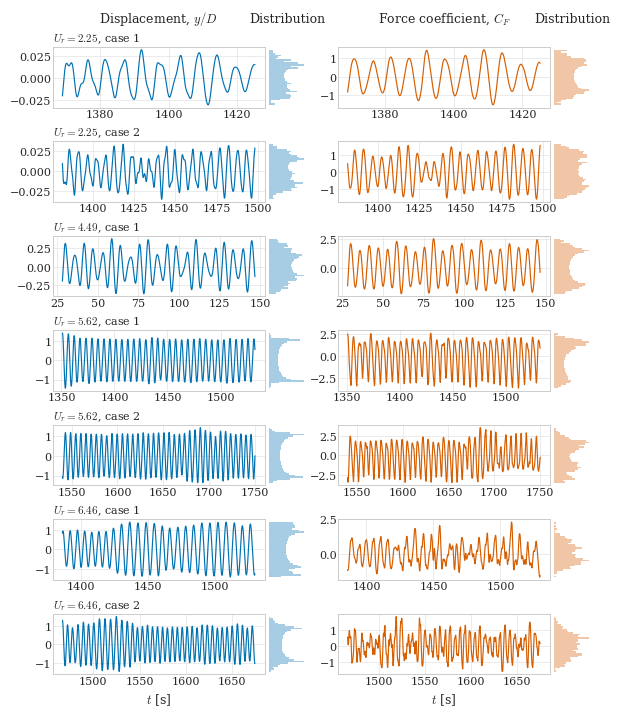

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


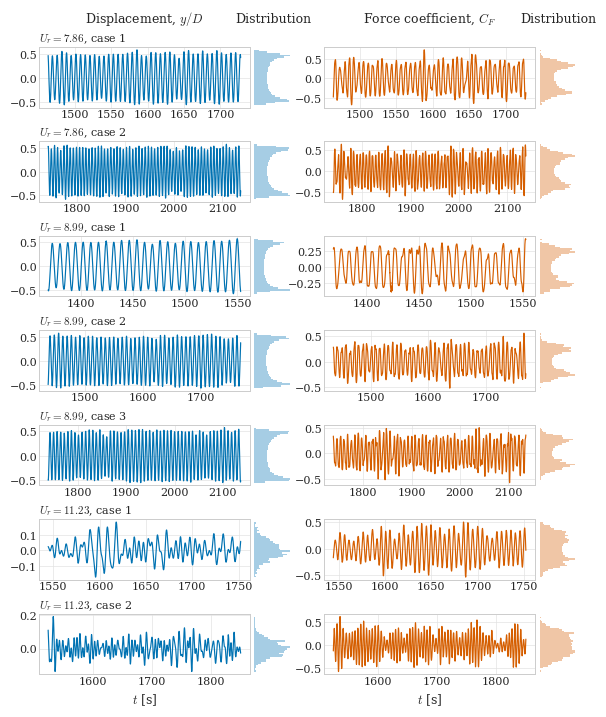

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


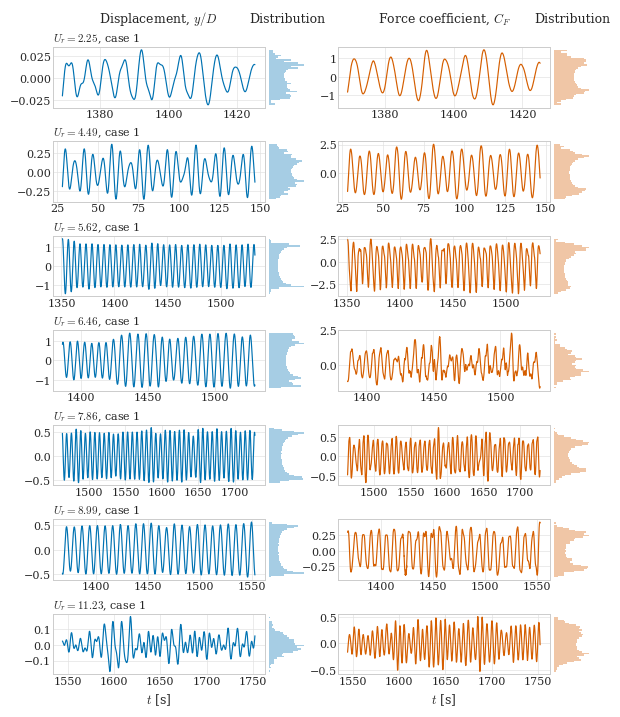

Saved CFD-only timeseries histogram figure(s):
- /Users/kasperslagstad/Desktop/Masterproject/figures/fig_04_cfd_timeseries_histograms_01.pdf
- /Users/kasperslagstad/Desktop/Masterproject/figures/fig_04_cfd_timeseries_histograms_02.pdf
Saved representative shortest-timeseries figure(s):
- /Users/kasperslagstad/Desktop/Masterproject/figures/fig_04_cfd_timeseries_histograms_representative.pdf


In [48]:
from __future__ import annotations

from matplotlib.gridspec import GridSpec

THESIS_FIGURE_WIDTH = 5.85
THESIS_AXIS_LABEL_SIZE = 9
THESIS_TICK_LABEL_SIZE = 8
THESIS_ANNOTATION_SIZE = 8

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Latin Modern Roman", "Computer Modern Roman", "DejaVu Serif"],
        "mathtext.fontset": "cm",
        "axes.labelsize": THESIS_AXIS_LABEL_SIZE,
        "xtick.labelsize": THESIS_TICK_LABEL_SIZE,
        "ytick.labelsize": THESIS_TICK_LABEL_SIZE,
        "legend.fontsize": THESIS_TICK_LABEL_SIZE,
        "axes.titlesize": THESIS_AXIS_LABEL_SIZE,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    }
)

CFD_HIST_BINS = 35
CFD_MAX_ROWS_PER_FIGURE = 7
CFD_TIMESERIES_X_MODE = "time"  # "time" keeps the pre-burn-in absolute time; use "natural_periods" for t/T_n.
CFD_TIMESERIES_OUTPUT_DIR = REPO_ROOT / "figures"
CFD_TIMESERIES_OUTPUT_BASENAME = "fig_04_cfd_timeseries_histograms"
CFD_DISPLACEMENT_COLOR = "#0072B2"
CFD_FORCE_COLOR = "#D55E00"


def _npz_first_array(data, keys) -> np.ndarray:
    for key in keys:
        if key in data.files:
            return np.asarray(data[key], dtype=float).reshape(-1)
    raise KeyError(f"None of the keys were found: {keys}")


def _npz_first_scalar(data, keys, default: float = float("nan")) -> float:
    for key in keys:
        if key in data.files:
            values = np.asarray(data[key], dtype=float).reshape(-1)
            finite = values[np.isfinite(values)]
            if finite.size:
                return float(finite[0])
    return float(default)


def _force_per_m_to_cf(force_per_m: np.ndarray, *, rho: float, diameter: float, flow_speed: np.ndarray | float) -> np.ndarray:
    force = np.asarray(force_per_m, dtype=float).reshape(-1)
    flow = np.asarray(flow_speed, dtype=float).reshape(-1)
    if flow.size == 1:
        flow = np.full(force.shape, float(flow[0]), dtype=float)
    if flow.size != force.size:
        raise ValueError(f"Expected flow speed length {force.size}, got {flow.size}.")
    denom = 0.5 * float(rho) * float(diameter) * flow * flow
    out = np.full(force.shape, np.nan, dtype=float)
    valid = np.isfinite(force) & np.isfinite(denom) & (np.abs(denom) > 0.0)
    out[valid] = force[valid] / denom[valid]
    return out


def load_cfd_timeseries(npz_path: Path) -> dict:
    with np.load(npz_path, allow_pickle=False) as data:
        time = _npz_first_array(data, ["time_dim", "time", "a"])
        diameter = _npz_first_scalar(data, ["diameter_m", "python_diameter_m"])
        rho = _npz_first_scalar(data, ["rho_kg_m3", "python_rho_kg_m3"])
        flow_speed = _npz_first_array(data, ["flow_speed_m_s", "python_flow_speed_m_s"])
        if flow_speed.size == 1:
            flow_speed = np.full(time.shape, float(flow_speed[0]), dtype=float)

        if "y_disp_nd" in data.files:
            y_over_d = np.asarray(data["y_disp_nd"], dtype=float).reshape(-1)
        else:
            displacement = _npz_first_array(data, ["y_disp_dim", "y", "b"])
            y_over_d = displacement / float(diameter)

        if "y_force_nd" in data.files:
            c_f = np.asarray(data["y_force_nd"], dtype=float).reshape(-1)
        else:
            force_per_m = _npz_first_array(data, ["y_force_per_m_dim", "force_per_m_dim", "c"])
            c_f = _force_per_m_to_cf(force_per_m, rho=rho, diameter=diameter, flow_speed=flow_speed)

        fn = _npz_first_scalar(data, ["structural_frequency_hz"])
        if not (np.isfinite(fn) and fn > 0.0):
            stiffness = _npz_first_scalar(data, ["stiffness_n_m", "python_stiffness_n_m"])
            effective_mass = _npz_first_scalar(data, ["effective_mass_kg", "python_effective_mass_kg"])
            fn = float(np.sqrt(stiffness / effective_mass) / (2.0 * np.pi))

        ur_effective = _npz_first_scalar(data, ["U_r_computed_scalar", "computed_ur", "U_r_computed_series"])
        if not np.isfinite(ur_effective):
            ur_effective = _npz_first_scalar(data, ["U_r_label_scalar", "label_ur", "U_r_label_series", "U_r"])

    n = min(time.size, y_over_d.size, c_f.size, flow_speed.size)
    if n < 2:
        raise ValueError(f"{npz_path} is too short to plot.")
    time = time[:n]
    y_over_d = y_over_d[:n]
    c_f = c_f[:n]
    valid = np.isfinite(time) & np.isfinite(y_over_d) & np.isfinite(c_f)
    if np.count_nonzero(valid) < 2:
        raise ValueError(f"{npz_path} has fewer than two finite CFD samples.")
    time = time[valid]
    y_over_d = y_over_d[valid]
    c_f = c_f[valid]
    return {
        "name": npz_path.stem,
        "path": npz_path,
        "time": time,
        "cycles": (time - float(time[0])) * float(fn),
        "y_over_d": y_over_d,
        "c_f": c_f,
        "ur_effective": float(ur_effective),
        "natural_frequency_hz": float(fn),
    }


def _assign_case_numbers_by_ur(series_list: list[dict]) -> None:
    grouped: dict[float, int] = {}
    for series in sorted(series_list, key=lambda item: (round(float(item["ur_effective"]), 6), item["name"])):
        key = round(float(series["ur_effective"]), 6)
        grouped[key] = grouped.get(key, 0) + 1
        series["case_index_for_ur"] = grouped[key]


def _series_duration(series: dict) -> float:
    time = np.asarray(series["time"], dtype=float).reshape(-1)
    finite = time[np.isfinite(time)]
    if finite.size < 2:
        return float("inf")
    return float(np.max(finite) - np.min(finite))


def select_shortest_timeseries_by_ur(series_list: list[dict]) -> list[dict]:
    if not series_list:
        return []
    sorted_series = sorted(series_list, key=lambda item: (round(float(item["ur_effective"]), 6), item["name"]))
    _assign_case_numbers_by_ur(sorted_series)
    grouped: dict[float, list[dict]] = {}
    for series in sorted_series:
        grouped.setdefault(round(float(series["ur_effective"]), 6), []).append(series)
    representatives = []
    for _ur_key, entries in sorted(grouped.items(), key=lambda item: item[0]):
        representatives.append(
            min(
                entries,
                key=lambda item: (_series_duration(item), np.asarray(item["time"]).size, item["name"]),
            )
        )
    return representatives


def _hist_edges(values: np.ndarray, bins: int) -> np.ndarray | int:
    finite = np.asarray(values, dtype=float).reshape(-1)
    finite = finite[np.isfinite(finite)]
    if finite.size == 0:
        return int(bins)
    vmin = float(np.min(finite))
    vmax = float(np.max(finite))
    if not np.isfinite(vmin) or not np.isfinite(vmax) or np.isclose(vmin, vmax):
        delta = max(abs(vmin), 1.0) * 1.0e-3
        return np.linspace(vmin - delta, vmax + delta, int(bins) + 1)
    return np.linspace(vmin, vmax, int(bins) + 1)


def _plot_side_hist(ax_hist, values: np.ndarray, *, bins: int, color: str) -> None:
    finite = np.asarray(values, dtype=float).reshape(-1)
    finite = finite[np.isfinite(finite)]
    ax_hist.hist(
        finite,
        bins=_hist_edges(finite, bins),
        orientation="horizontal",
        color=color,
        alpha=0.35,
        edgecolor="none",
    )
    ax_hist.set_xlabel("")
    ax_hist.set_ylabel("")
    ax_hist.tick_params(axis="both", which="both", left=False, bottom=False, labelleft=False, labelbottom=False)
    ax_hist.grid(False)
    for spine in ax_hist.spines.values():
        spine.set_visible(False)


def plot_cfd_timeseries_histograms(
    series_list: list[dict],
    *,
    bins: int = CFD_HIST_BINS,
    max_rows_per_figure: int = CFD_MAX_ROWS_PER_FIGURE,
    x_mode: str = CFD_TIMESERIES_X_MODE,
    output_dir: Path = CFD_TIMESERIES_OUTPUT_DIR,
    output_basename: str = CFD_TIMESERIES_OUTPUT_BASENAME,
) -> list[Path]:
    if not series_list:
        raise ValueError("No CFD series were provided.")
    x_key = "cycles" if str(x_mode).lower() == "natural_periods" else "time"
    x_label = r"$t/T_n$" if x_key == "cycles" else r"$t$ [s]"
    sorted_series = sorted(series_list, key=lambda item: (float(item["ur_effective"]), item["name"]))
    if any("case_index_for_ur" not in series for series in sorted_series):
        _assign_case_numbers_by_ur(sorted_series)

    rows_per_fig = max(1, int(max_rows_per_figure))
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    saved_paths: list[Path] = []

    for chunk_idx, start in enumerate(range(0, len(sorted_series), rows_per_fig), start=1):
        chunk = sorted_series[start : start + rows_per_fig]
        n_rows = len(chunk)
        fig_height = min(7.4, max(2.4, 1.03 * n_rows))
        fig = plt.figure(figsize=(THESIS_FIGURE_WIDTH, fig_height), constrained_layout=False)
        gs = GridSpec(
            n_rows,
            5,
            figure=fig,
            width_ratios=[4.0, 0.7, 0.45, 4.0, 0.7],
            wspace=0.04,
            hspace=0.56,
        )

        for row_idx, series in enumerate(chunk):
            ax_y = fig.add_subplot(gs[row_idx, 0])
            ax_y_hist = fig.add_subplot(gs[row_idx, 1], sharey=ax_y)
            ax_f = fig.add_subplot(gs[row_idx, 3])
            ax_f_hist = fig.add_subplot(gs[row_idx, 4], sharey=ax_f)

            x = np.asarray(series[x_key], dtype=float)
            y_over_d = np.asarray(series["y_over_d"], dtype=float)
            c_f = np.asarray(series["c_f"], dtype=float)
            ax_y.plot(x, y_over_d, color=CFD_DISPLACEMENT_COLOR, linewidth=0.85)
            ax_f.plot(x, c_f, color=CFD_FORCE_COLOR, linewidth=0.85)
            _plot_side_hist(ax_y_hist, y_over_d, bins=bins, color=CFD_DISPLACEMENT_COLOR)
            _plot_side_hist(ax_f_hist, c_f, bins=bins, color=CFD_FORCE_COLOR)

            label = rf"$U_r={float(series['ur_effective']):.2f}$, case {int(series['case_index_for_ur'])}"
            ax_y.text(
                0.0,
                1.035,
                label,
                transform=ax_y.transAxes,
                ha="left",
                va="bottom",
                fontsize=THESIS_ANNOTATION_SIZE,
                clip_on=False,
            )
            if row_idx == 0:
                ax_y.set_title(r"Displacement, $y/D$", pad=18)
                ax_y_hist.set_title("Distribution", pad=18)
                ax_f.set_title(r"Force coefficient, $C_F$", pad=18)
                ax_f_hist.set_title("Distribution", pad=18)

            ax_y.grid(True, color="0.88", linewidth=0.45)
            ax_f.grid(True, color="0.88", linewidth=0.45)
            for ax in (ax_y, ax_f):
                ax.tick_params(axis="both", labelsize=THESIS_TICK_LABEL_SIZE, pad=1)
                for spine in ax.spines.values():
                    spine.set_linewidth(0.7)
            if row_idx == n_rows - 1:
                ax_y.set_xlabel(x_label)
                ax_f.set_xlabel(x_label)
            else:
                ax_y.set_xlabel("")
                ax_f.set_xlabel("")

        fig.subplots_adjust(left=0.075, right=0.995, bottom=0.07, top=0.94)
        suffix = f"_{chunk_idx:02d}" if len(sorted_series) > rows_per_fig else ""
        output_path = output_dir / f"{output_basename}{suffix}.pdf"
        fig.savefig(output_path, format="pdf", bbox_inches="tight", pad_inches=0.02, dpi=300)
        saved_paths.append(output_path)
        if "ipykernel" in sys.modules:
            plt.show()
        else:
            plt.close(fig)
    return saved_paths


cfd_series = [load_cfd_timeseries(path) for path in files]
cfd_timeseries_histogram_paths = plot_cfd_timeseries_histograms(cfd_series)
cfd_representative_series = select_shortest_timeseries_by_ur(cfd_series)
cfd_representative_timeseries_histogram_paths = plot_cfd_timeseries_histograms(
    cfd_representative_series,
    output_basename="fig_04_cfd_timeseries_histograms_representative",
)
print("Saved CFD-only timeseries histogram figure(s):")
for path in cfd_timeseries_histogram_paths:
    print(f"- {path}")
print("Saved representative shortest-timeseries figure(s):")
for path in cfd_representative_timeseries_histogram_paths:
    print(f"- {path}")


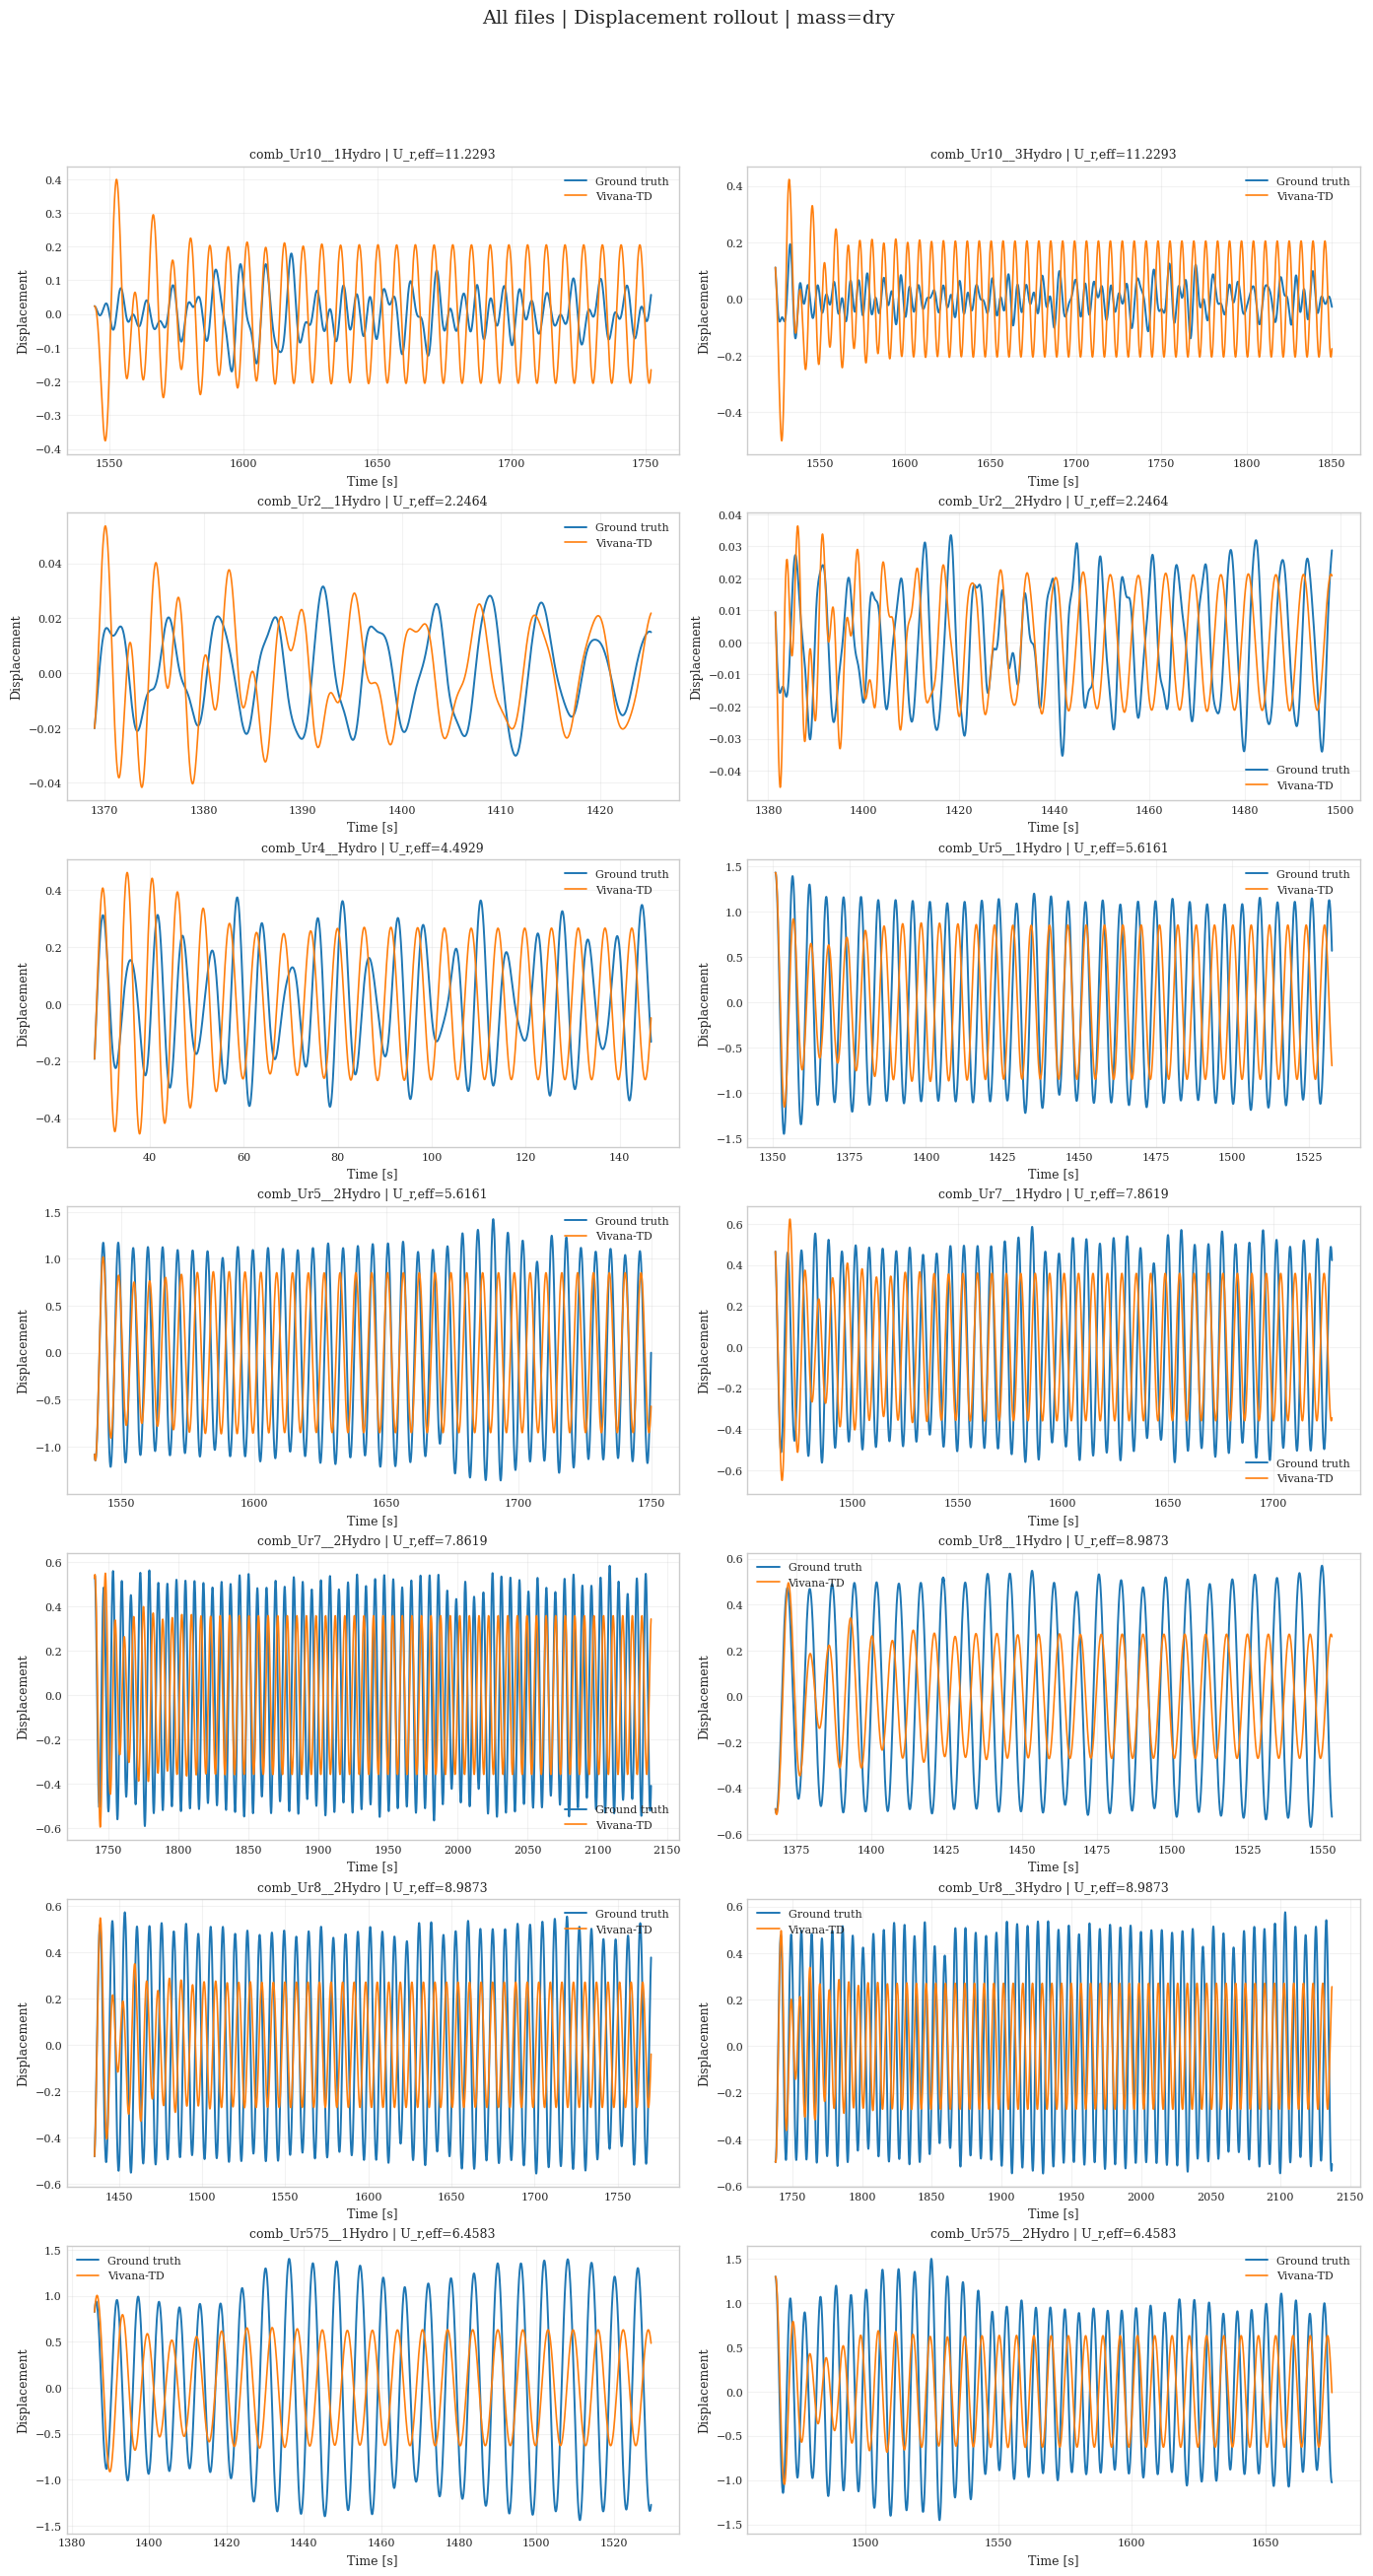

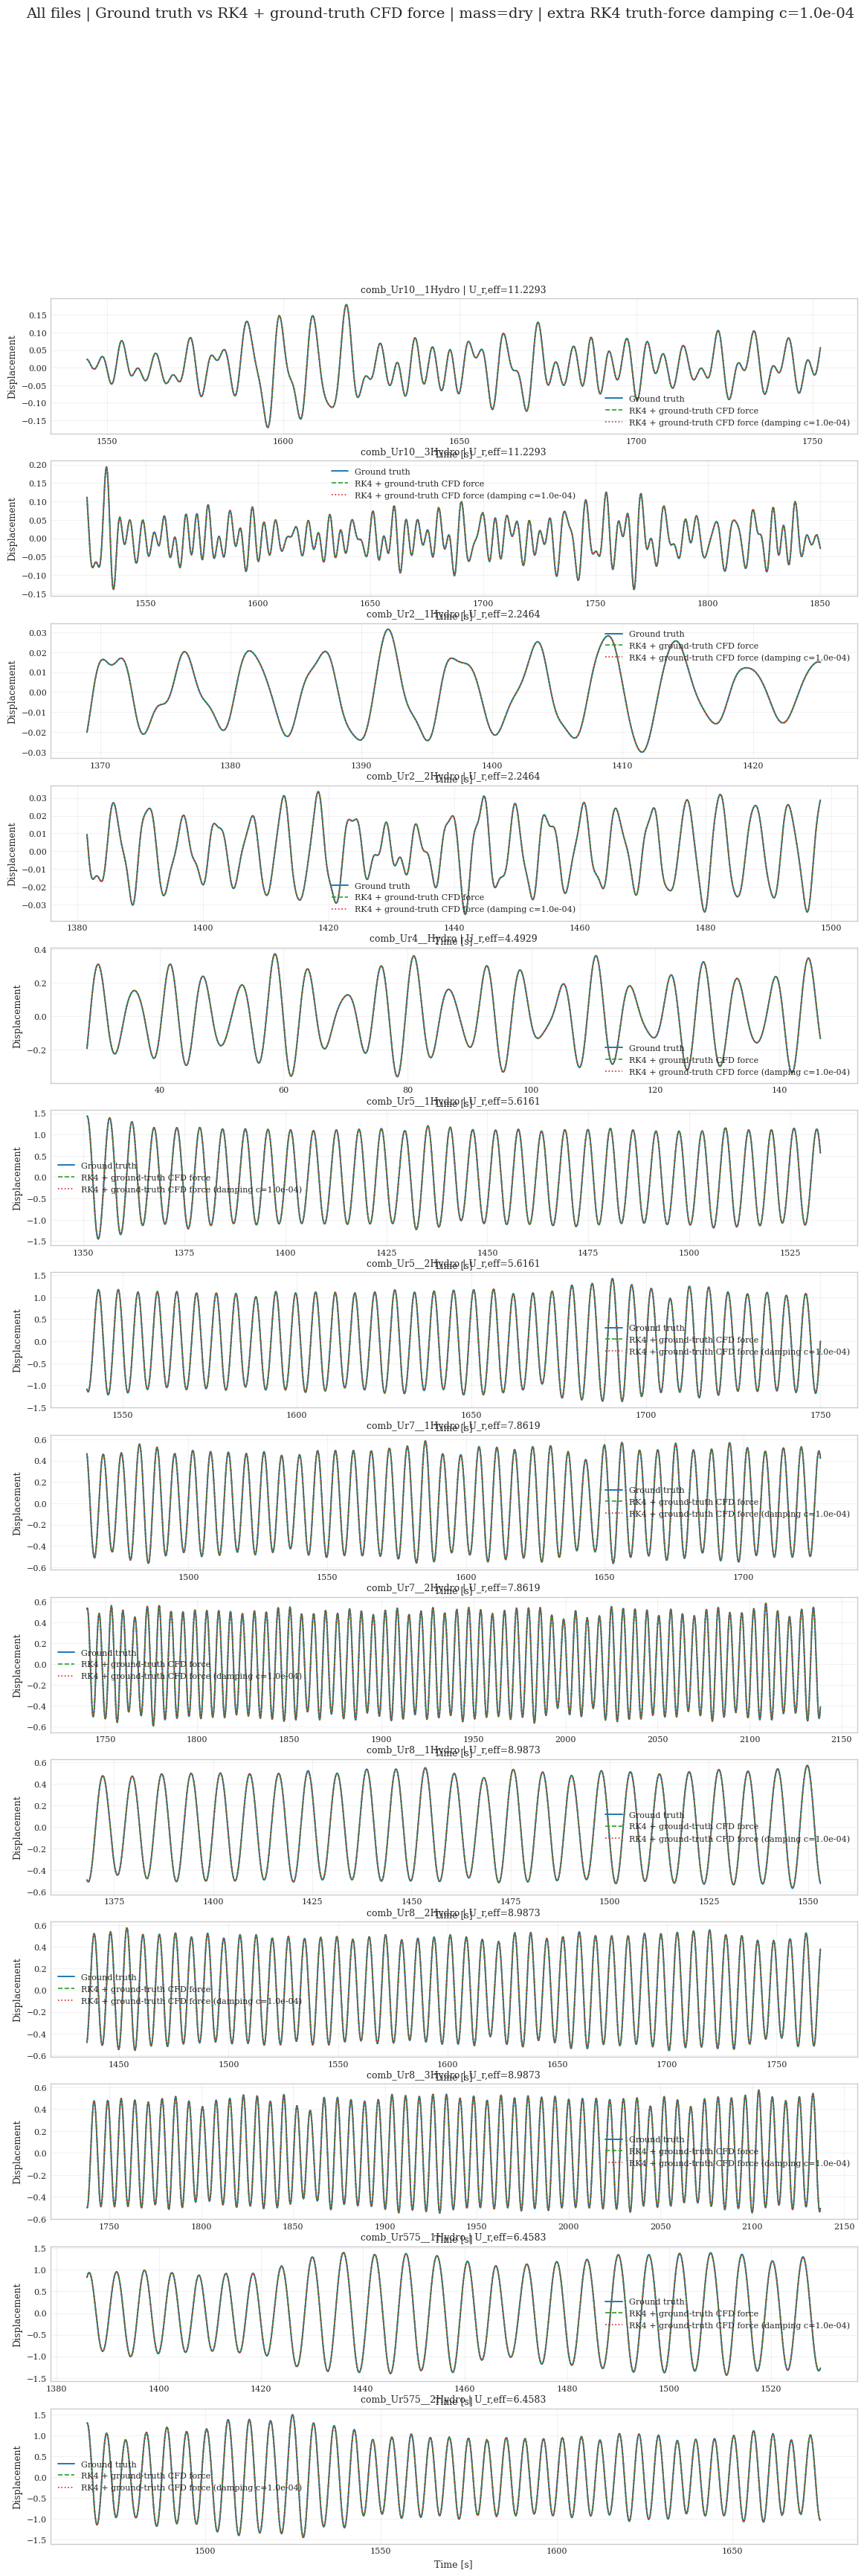

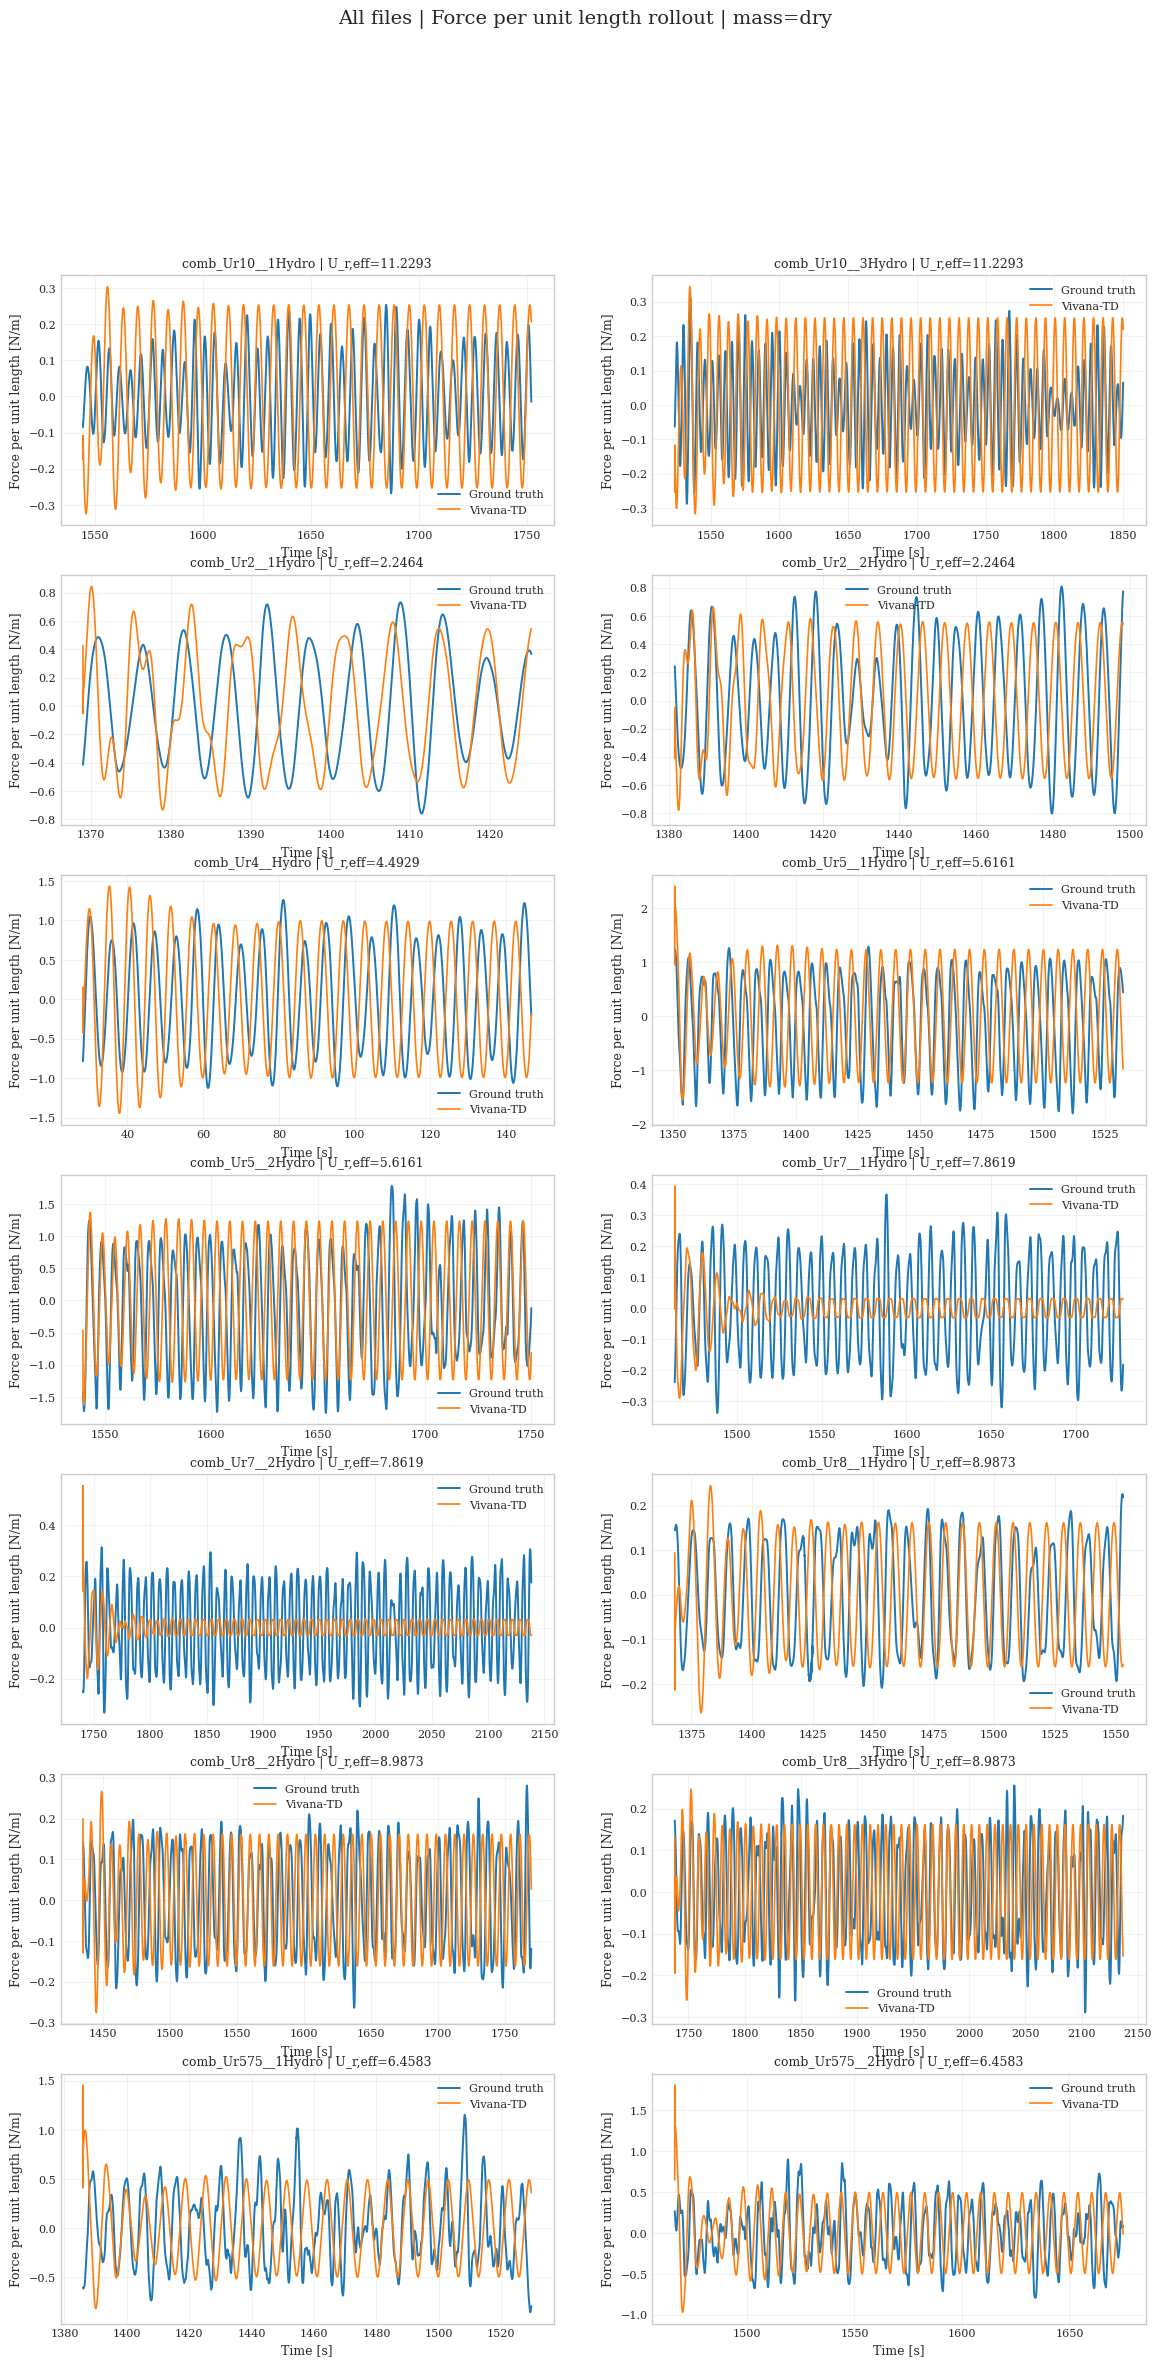

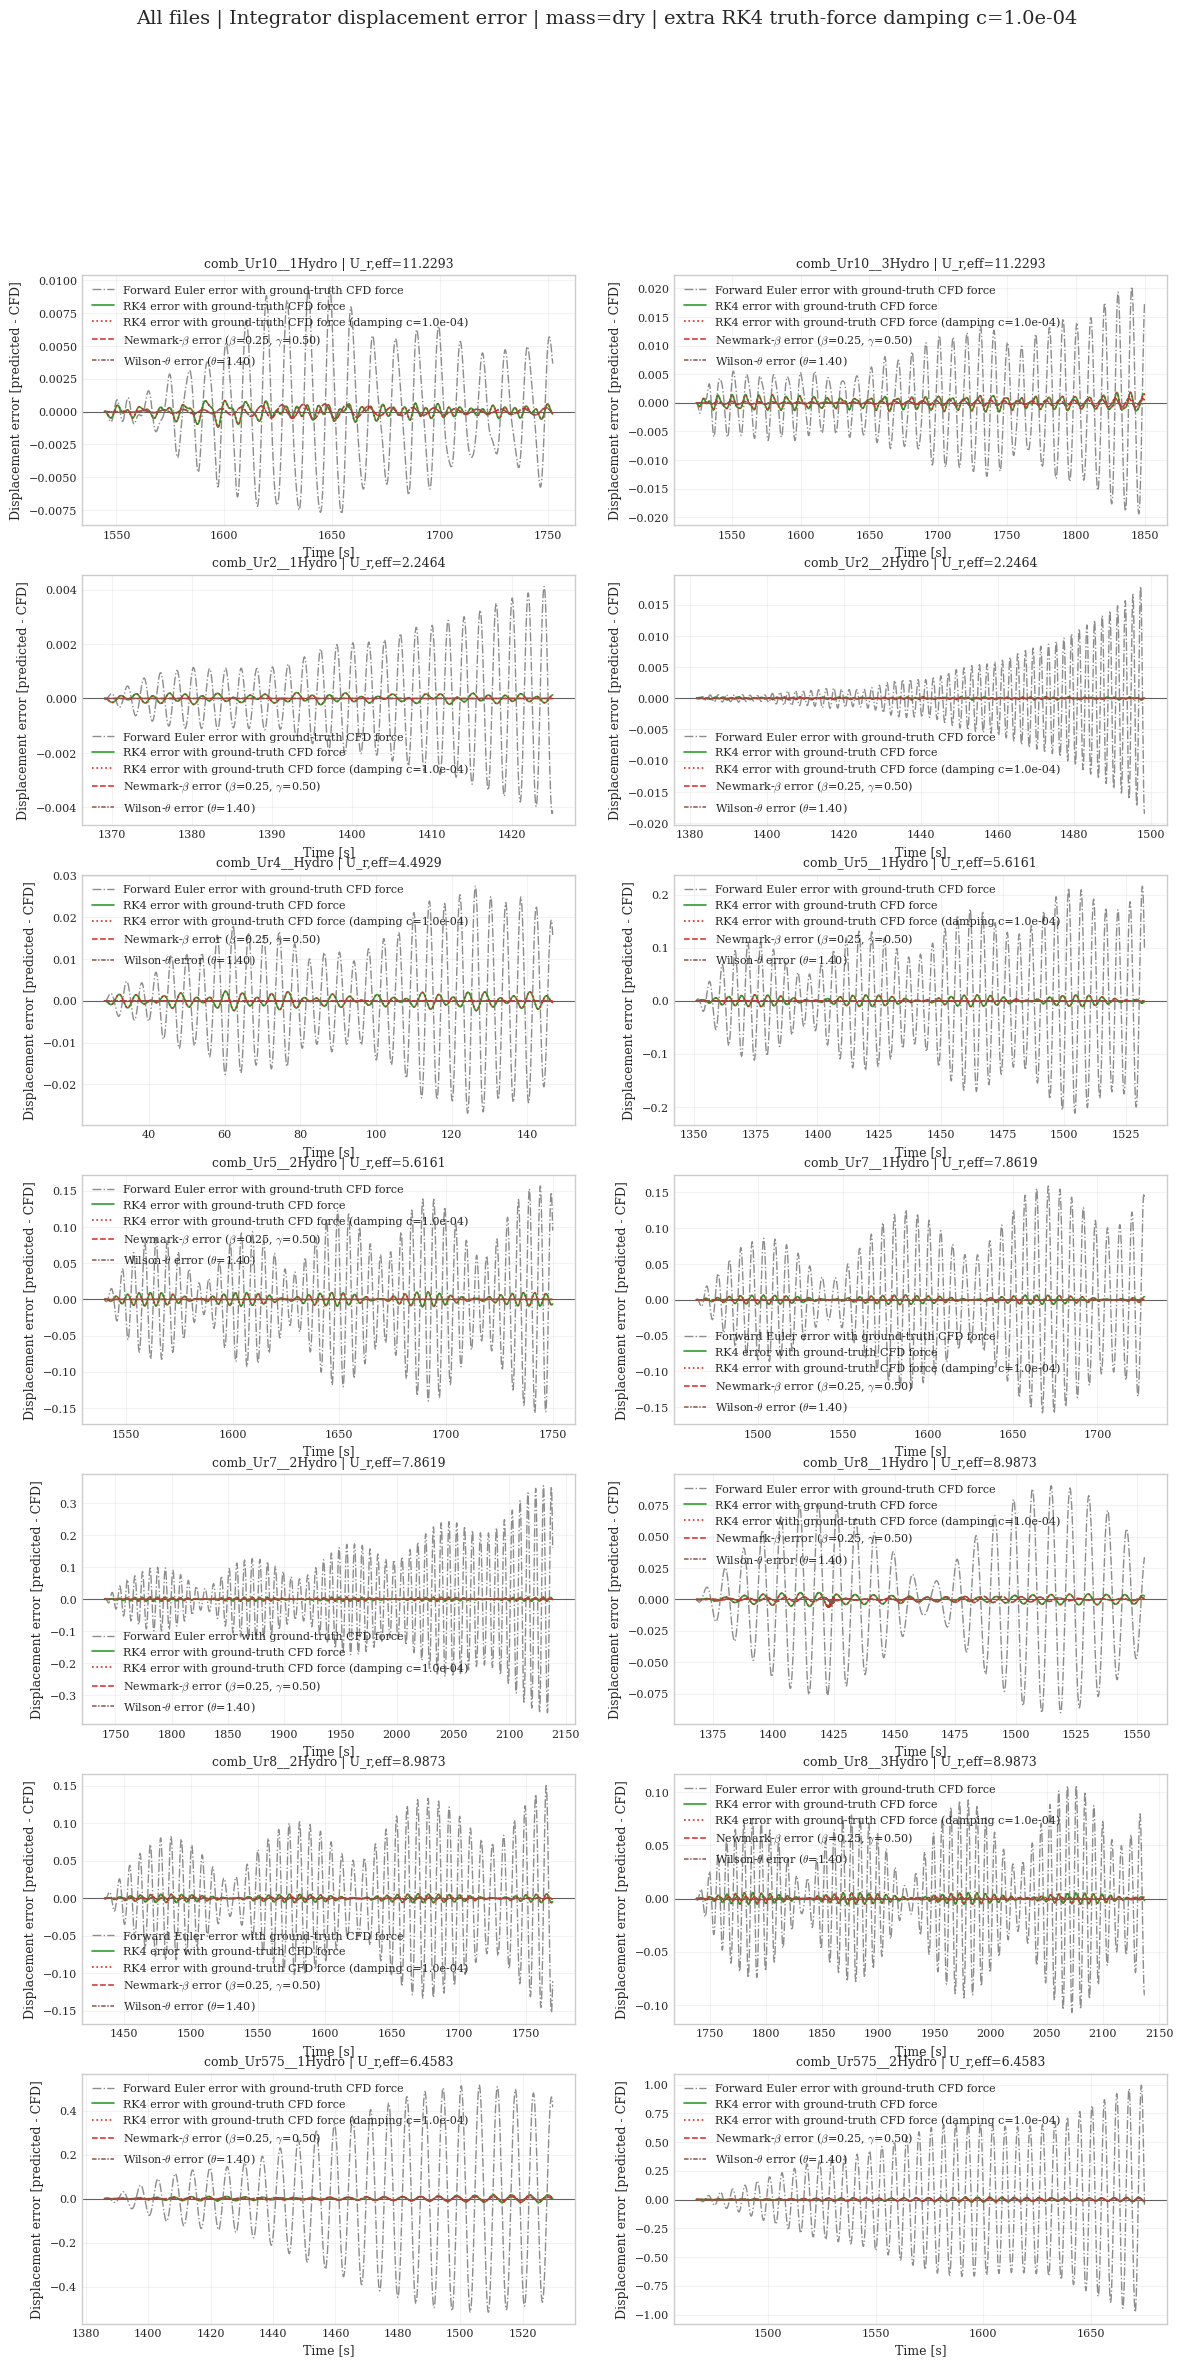

In [49]:
files = iter_all_npz_files(DATASET_ROOT)
series_rollouts = []
for npz_path in files:
    series = load_series(npz_path)
    rollout = simulate_vivana_td(
        series,
        td_params=TD_PARAMS,
        mass_source=TD_MASS_SOURCE,
        forced_truth_damping_override=FORCED_TRUTH_DAMPING_C_OVERRIDE,
    )
    series_rollouts.append((series, rollout))

if not series_rollouts:
    raise ValueError('No NPZ files found to plot.')

n_cases = len(series_rollouts)
ncols = 2 if n_cases > 1 else 1
nrows = math.ceil(n_cases / ncols)

fig_disp, axes_disp = plt.subplots(nrows, ncols, figsize=(FIGSIZE[0], 3.8 * nrows), squeeze=False)
fig_disp.suptitle(f"All files | Displacement rollout | mass={TD_MASS_SOURCE}", fontsize=14)

fig_rk4_compare, axes_rk4_compare = plt.subplots(n_cases, 1, figsize=(FIGSIZE[0], 2.8 * n_cases), squeeze=False)
rk4_compare_title = f"All files | Ground truth vs RK4 + ground-truth CFD force | mass={TD_MASS_SOURCE}"
if FORCED_TRUTH_DAMPING_C_OVERRIDE is not None:
    rk4_compare_title += f" | extra RK4 truth-force damping c={FORCED_TRUTH_DAMPING_C_OVERRIDE:.1e}"
fig_rk4_compare.suptitle(rk4_compare_title, fontsize=14)

fig_force, axes_force = plt.subplots(nrows, ncols, figsize=(FIGSIZE[0], 3.8 * nrows), squeeze=False)
fig_force.suptitle(f"All files | Force per unit length rollout | mass={TD_MASS_SOURCE}", fontsize=14)

fig_integrator, axes_integrator = plt.subplots(nrows, ncols, figsize=(FIGSIZE[0], 3.8 * nrows), squeeze=False)
integrator_title = f"All files | Integrator displacement error | mass={TD_MASS_SOURCE}"
if FORCED_TRUTH_DAMPING_C_OVERRIDE is not None:
    integrator_title += f" | extra RK4 truth-force damping c={FORCED_TRUTH_DAMPING_C_OVERRIDE:.1e}"
fig_integrator.suptitle(integrator_title, fontsize=14)

flat_disp = axes_disp.reshape(-1)
flat_force = axes_force.reshape(-1)
flat_integrator = axes_integrator.reshape(-1)
flat_rk4_compare = axes_rk4_compare.reshape(-1)

for idx, (series, rollout) in enumerate(series_rollouts):
    title = f"{series['name']} | U_r,eff={series['ur_effective']:.4f}"

    ax_disp = flat_disp[idx]
    ax_disp.plot(series["time"], series["displacement"], label="Ground truth", color="tab:blue", linewidth=1.4)
    ax_disp.plot(series["time"], rollout["displacement_td"], label="Vivana-TD", color="tab:orange", linewidth=1.2)
    ax_disp.set_title(title)
    ax_disp.set_ylabel("Displacement")
    ax_disp.set_xlabel("Time [s]")
    ax_disp.grid(True, alpha=0.25)
    ax_disp.legend(loc="best")

    ax_rk4_compare = flat_rk4_compare[idx]
    ax_rk4_compare.plot(series["time"], series["displacement"], label="Ground truth", color="tab:blue", linewidth=1.4)
    ax_rk4_compare.plot(series["time"], rollout["displacement_rk4_truth_force"], label="RK4 + ground-truth CFD force", color="tab:green", linewidth=1.2, linestyle="--")
    if rollout["displacement_rk4_truth_force_damped"] is not None:
        ax_rk4_compare.plot(
            series["time"],
            rollout["displacement_rk4_truth_force_damped"],
            label=f"RK4 + ground-truth CFD force (damping c={FORCED_TRUTH_DAMPING_C_OVERRIDE:.1e})",
            color="tab:red",
            linewidth=1.2,
            linestyle=":",
        )
    ax_rk4_compare.set_title(title)
    ax_rk4_compare.set_ylabel("Displacement")
    ax_rk4_compare.set_xlabel("Time [s]")
    ax_rk4_compare.grid(True, alpha=0.25)
    ax_rk4_compare.legend(loc="best")

    ax_force = flat_force[idx]
    ax_force.plot(series["time"], series["force_per_m"], label="Ground truth", color="tab:blue", linewidth=1.4)
    ax_force.plot(series["time"], rollout["force_td"], label="Vivana-TD", color="tab:orange", linewidth=1.2)
    ax_force.set_title(title)
    ax_force.set_ylabel("Force per unit length [N/m]")
    ax_force.set_xlabel("Time [s]")
    ax_force.grid(True, alpha=0.25)
    ax_force.legend(loc="best")

    ax_integrator = flat_integrator[idx]
    displacement_truth = np.asarray(series["displacement"], dtype=float)
    forward_euler_error = np.asarray(rollout["displacement_forward_euler_truth_force"], dtype=float) - displacement_truth
    rk4_error = np.asarray(rollout["displacement_rk4_truth_force"], dtype=float) - displacement_truth
    rk4_damped_error = None
    if rollout["displacement_rk4_truth_force_damped"] is not None:
        rk4_damped_error = np.asarray(rollout["displacement_rk4_truth_force_damped"], dtype=float) - displacement_truth
    newmark_error = np.asarray(rollout["displacement_newmark_truth_force"], dtype=float) - displacement_truth
    wilson_theta_error = np.asarray(rollout["displacement_wilson_theta_truth_force"], dtype=float) - displacement_truth
    ax_integrator.axhline(0.0, color="black", linewidth=0.8, alpha=0.6)
    ax_integrator.plot(series["time"], forward_euler_error, label="Forward Euler error with ground-truth CFD force", color="0.55", linewidth=1.0, linestyle="-.")
    ax_integrator.plot(series["time"], rk4_error, label="RK4 error with ground-truth CFD force", color="tab:green", linewidth=1.2)
    if rk4_damped_error is not None:
        ax_integrator.plot(
            series["time"],
            rk4_damped_error,
            label=f"RK4 error with ground-truth CFD force (damping c={FORCED_TRUTH_DAMPING_C_OVERRIDE:.1e})",
            color="tab:red",
            linewidth=1.2,
            linestyle=":",
        )
    ax_integrator.plot(series["time"], newmark_error, label=f"Newmark-$\\beta$ error ($\\beta$={NEWMARK_BETA:.2f}, $\\gamma$={NEWMARK_GAMMA:.2f})", color="tab:red", linewidth=1.1, linestyle="--")
    ax_integrator.plot(series["time"], wilson_theta_error, label=f"Wilson-$\\theta$ error ($\\theta$={WILSON_THETA:.2f})", color="tab:brown", linewidth=1.1, linestyle=(0, (3, 1, 1, 1)))
    ax_integrator.set_title(title)
    ax_integrator.set_ylabel("Displacement error [predicted - CFD]")
    ax_integrator.set_xlabel("Time [s]")
    ax_integrator.grid(True, alpha=0.25)
    ax_integrator.legend(loc="best")

for extra_ax in flat_disp[n_cases:]:
    extra_ax.axis("off")
for extra_ax in flat_force[n_cases:]:
    extra_ax.axis("off")
for extra_ax in flat_integrator[n_cases:]:
    extra_ax.axis("off")

fig_disp.tight_layout()
fig_disp.subplots_adjust(top=0.92)
plt.show()

fig_rk4_compare.tight_layout()
fig_rk4_compare.subplots_adjust(top=0.98 if n_cases <= 2 else 0.99)
plt.show()

fig_force.tight_layout()
fig_force.subplots_adjust(top=0.92)
plt.show()

fig_integrator.tight_layout()
fig_integrator.subplots_adjust(top=0.92)
plt.show()

## Displacement Integrator Errors vs Reduced Velocity

Evaluate full-series displacement percent error versus effective reduced velocity for the ground-truth-force replay under Forward Euler, RK4, Newmark-beta, and Wilson-theta. The normalization uses the RMS of the ground-truth displacement signal, i.e. `percent error = 100 * RMSE(y_pred, y_true) / RMSE(0, y_true)`. The companion panels compare displacement standard deviation and dominant frequency against the CFD ground truth. All y-axes are logarithmic.


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


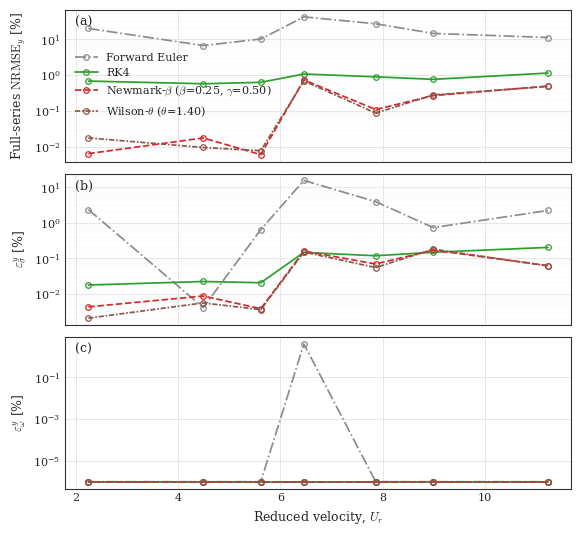

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


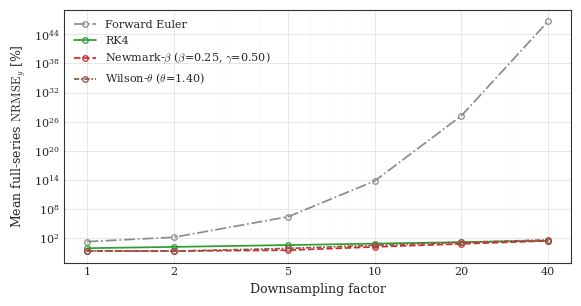

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


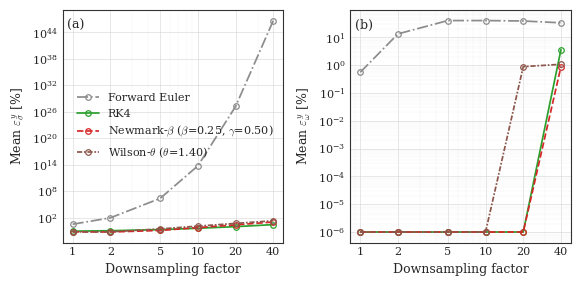

Generated PDF figure paths:
/Users/kasperslagstad/Desktop/Masterproject/figures/integrator_errors_vs_ur.pdf
/Users/kasperslagstad/Desktop/Masterproject/figures/nrmse_vs_downsampling_factor.pdf
/Users/kasperslagstad/Desktop/Masterproject/figures/displacement_std_frequency_error_vs_downsampling_factor.pdf
Mean full-series displacement NRMSE_y summary by effective reduced velocity:
Forward Euler                                    | U_r,eff=2.2464 | n_cases= 2 | full_series_nrmse_y=1.966403e+01%
Forward Euler                                    | U_r,eff=4.4929 | n_cases= 1 | full_series_nrmse_y=6.568283e+00%
Forward Euler                                    | U_r,eff=5.6161 | n_cases= 2 | full_series_nrmse_y=9.977683e+00%
Forward Euler                                    | U_r,eff=6.4583 | n_cases= 2 | full_series_nrmse_y=4.125298e+01%
Forward Euler                                    | U_r,eff=7.8619 | n_cases= 2 | full_series_nrmse_y=2.653294e+01%
Forward Euler                              

In [50]:
integrator_order = [
    "Forward Euler",
    "RK4",
    f"Newmark-$\\beta$ ($\\beta$={NEWMARK_BETA:.2f}, $\\gamma$={NEWMARK_GAMMA:.2f})",
    f"Wilson-$\\theta$ ($\\theta$={WILSON_THETA:.2f})",
]
colors = {
    "Forward Euler": "0.55",
    "RK4": "tab:green",
    f"Newmark-$\\beta$ ($\\beta$={NEWMARK_BETA:.2f}, $\\gamma$={NEWMARK_GAMMA:.2f})": "tab:red",
    f"Wilson-$\\theta$ ($\\theta$={WILSON_THETA:.2f})": "tab:brown",
}
linestyles = {
    "Forward Euler": "-.",
    "RK4": "-",
    f"Newmark-$\\beta$ ($\\beta$={NEWMARK_BETA:.2f}, $\\gamma$={NEWMARK_GAMMA:.2f})": "--",
    f"Wilson-$\\theta$ ($\\theta$={WILSON_THETA:.2f})": (0, (3, 1, 1, 1)),
}
ERROR_SCALE_PERCENT = 100.0
PLOT_ERROR_FLOOR_PERCENT = 1.0e-6
FIGURE_DPI = 300
THESIS_FIGSIZE_SINGLE = (5.85, 3.1)
THESIS_FIGSIZE_TWO_PANEL = (5.85, 2.9)
THESIS_FIGSIZE_UR_STACK = (5.85, 5.4)
BASE_FONT_SIZE = 8
AXIS_LABEL_FONT_SIZE = 9
TICK_FONT_SIZE = 8
LEGEND_FONT_SIZE = 8
PANEL_LABEL_FONT_SIZE = 9
LINE_WIDTH = 1.25
MARKER_SIZE = 4.0
SPINE_LINE_WIDTH = 0.8
SPINE_COLOR = "0.20"
GRID_COLOR = "0.82"
GRID_MINOR_COLOR = "0.90"

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman", "Computer Modern Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "font.size": BASE_FONT_SIZE,
    "axes.labelsize": AXIS_LABEL_FONT_SIZE,
    "axes.titlesize": PANEL_LABEL_FONT_SIZE,
    "axes.linewidth": SPINE_LINE_WIDTH,
    "xtick.labelsize": TICK_FONT_SIZE,
    "ytick.labelsize": TICK_FONT_SIZE,
    "legend.fontsize": LEGEND_FONT_SIZE,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.dpi": FIGURE_DPI,
})


def apply_axes_style(ax) -> None:
    ax.grid(True, which="major", color=GRID_COLOR, linewidth=0.5, alpha=0.75)
    ax.grid(True, which="minor", color=GRID_MINOR_COLOR, linewidth=0.35, alpha=0.45)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(SPINE_LINE_WIDTH)
        spine.set_edgecolor(SPINE_COLOR)


def add_panel_label(ax, index: int) -> None:
    ax.text(
        0.02,
        0.96,
        f"({chr(ord('a') + int(index))})",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=PANEL_LABEL_FONT_SIZE,
    )


def save_thesis_figure(fig, output_stem: Path) -> None:
    fig.savefig(output_stem.with_suffix(".pdf"), format="pdf", bbox_inches="tight", pad_inches=0.02, dpi=FIGURE_DPI)
    fig.savefig(output_stem.with_suffix(".png"), dpi=FIGURE_DPI, bbox_inches="tight", pad_inches=0.03)


def compute_rmse(predicted: np.ndarray, truth: np.ndarray) -> float:
    predicted = np.asarray(predicted, dtype=float).reshape(-1)
    truth = np.asarray(truth, dtype=float).reshape(-1)
    n = min(predicted.size, truth.size)
    if n == 0:
        return float("nan")
    error = predicted[:n] - truth[:n]
    finite = np.isfinite(error)
    if not np.any(finite):
        return float("nan")
    return float(np.sqrt(np.mean(np.square(error[finite]))))


def compute_truth_signal_rmse(truth: np.ndarray) -> float:
    truth = np.asarray(truth, dtype=float).reshape(-1)
    finite = np.isfinite(truth)
    if not np.any(finite):
        return float("nan")
    return float(np.sqrt(np.mean(np.square(truth[finite]))))


def compute_nrmse(predicted: np.ndarray, truth: np.ndarray) -> float:
    rmse = compute_rmse(predicted, truth)
    truth_rmse = compute_truth_signal_rmse(truth)
    if not (np.isfinite(rmse) and np.isfinite(truth_rmse) and truth_rmse > 0.0):
        return float("nan")
    return float(rmse / truth_rmse)


def compute_dominant_frequency_hz(time: np.ndarray, values: np.ndarray) -> float:
    time = np.asarray(time, dtype=float).reshape(-1)
    values = np.asarray(values, dtype=float).reshape(-1)
    n = min(time.size, values.size)
    if n < 4:
        return float("nan")
    time = time[:n]
    values = values[:n]
    finite = np.isfinite(time) & np.isfinite(values)
    if np.count_nonzero(finite) < 4:
        return float("nan")
    time = time[finite]
    values = values[finite]
    dt = float(np.median(np.diff(time)))
    if not (np.isfinite(dt) and dt > 0.0):
        return float("nan")
    demeaned = values - float(np.mean(values))
    if not np.any(np.isfinite(demeaned)) or float(np.std(demeaned)) <= 0.0:
        return float("nan")
    freqs = np.fft.rfftfreq(demeaned.size, d=dt)
    spectrum = np.abs(np.fft.rfft(demeaned))
    if freqs.size <= 1:
        return float("nan")
    idx = int(np.argmax(spectrum[1:]) + 1)
    return float(freqs[idx])


def relative_abs_error_percent(predicted: float, truth: float) -> float:
    predicted = float(predicted)
    truth = float(truth)
    if not (np.isfinite(predicted) and np.isfinite(truth) and abs(truth) > 0.0):
        return float("nan")
    return float(ERROR_SCALE_PERCENT * abs(predicted - truth) / abs(truth))


def aggregate_integrator_records(records: list[dict], value_key: str) -> list[dict]:
    aggregate_groups = {}
    for record in records:
        ur_value = float(record["ur_effective"])
        if not np.isfinite(ur_value):
            continue
        key = (record["integrator"], ur_value)
        aggregate_groups.setdefault(key, []).append(record)

    aggregated = []
    for (integrator_name, ur_value), rows in sorted(aggregate_groups.items(), key=lambda item: (item[0][0], item[0][1])):
        values = np.asarray([row[value_key] for row in rows], dtype=float)
        finite = values[np.isfinite(values)]
        aggregated.append(
            {
                "integrator": integrator_name,
                "ur_effective": float(ur_value),
                "n_cases": len(rows),
                value_key: float(np.mean(finite)) if finite.size else float("nan"),
            }
        )
    return aggregated


def plot_metric_by_ur(ax, records: list[dict], value_key: str, ylabel: str) -> None:
    for integrator_name in integrator_order:
        rows = [
            record for record in records
            if record["integrator"] == integrator_name and np.isfinite(record["ur_effective"])
        ]
        rows.sort(key=lambda record: record["ur_effective"])
        if not rows:
            continue
        ur_sorted = np.asarray([record["ur_effective"] for record in rows], dtype=float)
        metric_sorted = np.asarray([record[value_key] for record in rows], dtype=float)
        ax.plot(
            ur_sorted,
            np.maximum(metric_sorted, PLOT_ERROR_FLOOR_PERCENT),
            marker="o",
            markersize=MARKER_SIZE,
            markerfacecolor="none",
            markeredgewidth=0.9,
            markeredgecolor=colors[integrator_name],
            linewidth=LINE_WIDTH,
            linestyle=linestyles[integrator_name],
            color=colors[integrator_name],
            label=integrator_name,
        )
    ax.set_ylabel(ylabel, fontsize=AXIS_LABEL_FONT_SIZE)
    ax.set_xlabel(r"Reduced velocity, $U_r$", fontsize=AXIS_LABEL_FONT_SIZE)
    ax.set_yscale("log")
    ax.tick_params(labelsize=TICK_FONT_SIZE)
    apply_axes_style(ax)


def downsample_series(series: dict, factor: int) -> dict:
    factor = int(factor)
    if factor <= 1:
        return dict(series)
    time = np.asarray(series["time"], dtype=float).reshape(-1)
    idx = np.arange(0, time.size, factor, dtype=int)
    if idx.size < 4:
        raise ValueError(f"Series {series.get('name', '<unknown>')} is too short for downsampling factor {factor}.")
    out = dict(series)
    for key, value in series.items():
        arr = np.asarray(value) if isinstance(value, np.ndarray) else None
        if arr is not None and arr.shape[:1] == (time.size,):
            out[key] = arr[idx].copy()
    out["name"] = f"{series['name']}__ds{factor}"
    out["downsampling_factor"] = factor
    return out


def build_truth_force_integrator_outputs(series: dict) -> dict[str, np.ndarray]:
    force_total = series["force_total"]
    return {
        "Forward Euler": simulate_structural_response_with_force_forward_euler(series, force_total, mass_source=TD_MASS_SOURCE)["displacement"],
        "RK4": simulate_structural_response_with_force_rk4(series, force_total, mass_source=TD_MASS_SOURCE)["displacement"],
        f"Newmark-$\\beta$ ($\\beta$={NEWMARK_BETA:.2f}, $\\gamma$={NEWMARK_GAMMA:.2f})": simulate_structural_response_with_force_newmark(
            series,
            force_total,
            mass_source=TD_MASS_SOURCE,
            beta=NEWMARK_BETA,
            gamma=NEWMARK_GAMMA,
        )["displacement"],
        f"Wilson-$\\theta$ ($\\theta$={WILSON_THETA:.2f})": simulate_structural_response_with_force_wilson_theta(
            series,
            force_total,
            mass_source=TD_MASS_SOURCE,
            theta=WILSON_THETA,
        )["displacement"],
    }


def add_metric_records_for_series(
    *,
    point_records: list[dict],
    scalar_records: list[dict],
    series: dict,
    integrator_outputs: dict[str, np.ndarray],
    extra_fields=None,
) -> None:
    extra_fields = dict(extra_fields or {})
    ur_value = float(series["ur_effective"])
    if not np.isfinite(ur_value):
        ur_value = float(series["ur"])
    time = np.asarray(series["time"], dtype=float)
    displacement_truth = np.asarray(series["displacement"], dtype=float)
    truth_std = float(np.std(displacement_truth[np.isfinite(displacement_truth)]))
    truth_freq = compute_dominant_frequency_hz(time, displacement_truth)
    for integrator_name, displacement_pred in integrator_outputs.items():
        displacement_pred = np.asarray(displacement_pred, dtype=float)
        pred_std = float(np.std(displacement_pred[np.isfinite(displacement_pred)]))
        pred_freq = compute_dominant_frequency_hz(time, displacement_pred)
        base = {
            "case": series["name"],
            "ur_effective": ur_value,
            "integrator": integrator_name,
            **extra_fields,
        }
        point_records.append(
            {
                **base,
                "displacement_error_percent": ERROR_SCALE_PERCENT * compute_nrmse(displacement_pred, displacement_truth),
            }
        )
        scalar_records.append(
            {
                **base,
                "disp_std_error_percent": relative_abs_error_percent(pred_std, truth_std),
                "disp_freq_error_percent": relative_abs_error_percent(pred_freq, truth_freq),
            }
        )


def aggregate_downsampling_records(records: list[dict], value_key: str) -> list[dict]:
    by_ur = {}
    for record in records:
        factor = int(record["downsampling_factor"])
        ur_value = float(record["ur_effective"])
        if not np.isfinite(ur_value):
            continue
        key = (record["integrator"], factor, ur_value)
        by_ur.setdefault(key, []).append(record)

    by_factor = {}
    for (integrator_name, factor, ur_value), rows in by_ur.items():
        values = np.asarray([row[value_key] for row in rows], dtype=float)
        finite = values[np.isfinite(values)]
        if not finite.size:
            continue
        by_factor.setdefault((integrator_name, factor), []).append(float(np.mean(finite)))

    aggregated = []
    for (integrator_name, factor), ur_means in sorted(by_factor.items(), key=lambda item: (item[0][0], item[0][1])):
        values = np.asarray(ur_means, dtype=float)
        finite = values[np.isfinite(values)]
        aggregated.append(
            {
                "integrator": integrator_name,
                "downsampling_factor": int(factor),
                "n_reduced_velocities": int(finite.size),
                value_key: float(np.mean(finite)) if finite.size else float("nan"),
            }
        )
    return aggregated


def plot_metric_by_downsampling(ax, records: list[dict], value_key: str, ylabel: str) -> None:
    for integrator_name in integrator_order:
        rows = [record for record in records if record["integrator"] == integrator_name]
        rows.sort(key=lambda record: record["downsampling_factor"])
        if not rows:
            continue
        factors = np.asarray([record["downsampling_factor"] for record in rows], dtype=float)
        metric = np.asarray([record[value_key] for record in rows], dtype=float)
        ax.plot(
            factors,
            np.maximum(metric, PLOT_ERROR_FLOOR_PERCENT),
            marker="o",
            markersize=MARKER_SIZE,
            markerfacecolor="none",
            markeredgewidth=0.9,
            markeredgecolor=colors[integrator_name],
            linewidth=LINE_WIDTH,
            linestyle=linestyles[integrator_name],
            color=colors[integrator_name],
            label=integrator_name,
        )
    ax.set_ylabel(ylabel, fontsize=AXIS_LABEL_FONT_SIZE)
    ax.set_xlabel("Downsampling factor", fontsize=AXIS_LABEL_FONT_SIZE)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xticks(list(DOWNSAMPLING_FACTORS))
    ax.set_xticklabels([str(int(factor)) for factor in DOWNSAMPLING_FACTORS])
    ax.tick_params(labelsize=TICK_FONT_SIZE)
    apply_axes_style(ax)


integrator_nrmse_cases = []
integrator_scalar_metric_cases = []
for series, rollout in series_rollouts:
    integrator_outputs = {
        "Forward Euler": rollout["displacement_forward_euler_truth_force"],
        "RK4": rollout["displacement_rk4_truth_force"],
        f"Newmark-$\\beta$ ($\\beta$={NEWMARK_BETA:.2f}, $\\gamma$={NEWMARK_GAMMA:.2f})": rollout["displacement_newmark_truth_force"],
        f"Wilson-$\\theta$ ($\\theta$={WILSON_THETA:.2f})": rollout["displacement_wilson_theta_truth_force"],
    }
    add_metric_records_for_series(
        point_records=integrator_nrmse_cases,
        scalar_records=integrator_scalar_metric_cases,
        series=series,
        integrator_outputs=integrator_outputs,
    )

if not integrator_nrmse_cases:
    raise ValueError("No displacement NRMSE records were computed.")

integrator_nrmse_by_ur = aggregate_integrator_records(integrator_nrmse_cases, "displacement_error_percent")
integrator_disp_std_by_ur = aggregate_integrator_records(integrator_scalar_metric_cases, "disp_std_error_percent")
integrator_disp_freq_by_ur = aggregate_integrator_records(integrator_scalar_metric_cases, "disp_freq_error_percent")

FIGURES_DIR = REPO_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

fig_ur, axes_ur = plt.subplots(3, 1, figsize=THESIS_FIGSIZE_UR_STACK, sharex=True)
plot_metric_by_ur(
    axes_ur[0],
    integrator_nrmse_by_ur,
    "displacement_error_percent",
    r"Full-series $\mathrm{NRMSE}_y$ [%]",
)
plot_metric_by_ur(
    axes_ur[1],
    integrator_disp_std_by_ur,
    "disp_std_error_percent",
    r"$\varepsilon_\sigma^y$ [%]",
)
plot_metric_by_ur(
    axes_ur[2],
    integrator_disp_freq_by_ur,
    "disp_freq_error_percent",
    r"$\varepsilon_\omega^y$ [%]",
)
for panel_idx, ax in enumerate(axes_ur):
    add_panel_label(ax, panel_idx)
for ax in axes_ur[:-1]:
    ax.set_xlabel("")
axes_ur[0].legend(loc="best", fontsize=LEGEND_FONT_SIZE, frameon=False)
fig_ur.tight_layout()
save_thesis_figure(fig_ur, FIGURES_DIR / "integrator_errors_vs_ur")
plt.show()

downsampling_nrmse_cases = []
downsampling_scalar_metric_cases = []
for factor in DOWNSAMPLING_FACTORS:
    for series, _rollout in series_rollouts:
        try:
            ds_series = downsample_series(series, int(factor))
        except ValueError:
            continue
        ds_outputs = build_truth_force_integrator_outputs(ds_series)
        add_metric_records_for_series(
            point_records=downsampling_nrmse_cases,
            scalar_records=downsampling_scalar_metric_cases,
            series=ds_series,
            integrator_outputs=ds_outputs,
            extra_fields={"downsampling_factor": int(factor)},
        )

downsampling_nrmse_by_factor = aggregate_downsampling_records(downsampling_nrmse_cases, "displacement_error_percent")
downsampling_disp_std_by_factor = aggregate_downsampling_records(downsampling_scalar_metric_cases, "disp_std_error_percent")
downsampling_disp_freq_by_factor = aggregate_downsampling_records(downsampling_scalar_metric_cases, "disp_freq_error_percent")

fig_ds_nrmse, ax_ds_nrmse = plt.subplots(1, 1, figsize=THESIS_FIGSIZE_SINGLE)
plot_metric_by_downsampling(
    ax_ds_nrmse,
    downsampling_nrmse_by_factor,
    "displacement_error_percent",
    r"Mean full-series $\mathrm{NRMSE}_y$ [%]",
)
ax_ds_nrmse.legend(loc="best", fontsize=LEGEND_FONT_SIZE, frameon=False)
fig_ds_nrmse.tight_layout()
save_thesis_figure(fig_ds_nrmse, FIGURES_DIR / "nrmse_vs_downsampling_factor")
plt.show()

fig_ds_scalar, axes_ds_scalar = plt.subplots(1, 2, figsize=THESIS_FIGSIZE_TWO_PANEL, sharex=True)
plot_metric_by_downsampling(
    axes_ds_scalar[0],
    downsampling_disp_std_by_factor,
    "disp_std_error_percent",
    r"Mean $\varepsilon_\sigma^y$ [%]",
)
plot_metric_by_downsampling(
    axes_ds_scalar[1],
    downsampling_disp_freq_by_factor,
    "disp_freq_error_percent",
    r"Mean $\varepsilon_\omega^y$ [%]",
)
for panel_idx, ax in enumerate(axes_ds_scalar):
    add_panel_label(ax, panel_idx)
axes_ds_scalar[0].legend(loc="best", fontsize=LEGEND_FONT_SIZE, frameon=False)
fig_ds_scalar.tight_layout()
save_thesis_figure(fig_ds_scalar, FIGURES_DIR / "displacement_std_frequency_error_vs_downsampling_factor")
plt.show()

generated_pdf_paths = [
    FIGURES_DIR / "integrator_errors_vs_ur.pdf",
    FIGURES_DIR / "nrmse_vs_downsampling_factor.pdf",
    FIGURES_DIR / "displacement_std_frequency_error_vs_downsampling_factor.pdf",
]
print("Generated PDF figure paths:")
for path in generated_pdf_paths:
    print(path.resolve())

print("Mean full-series displacement NRMSE_y summary by effective reduced velocity:")
for record in sorted(integrator_nrmse_by_ur, key=lambda row: (row["integrator"], row["ur_effective"])):
    print(
        f"{record['integrator']:<48} | U_r,eff={record['ur_effective']:.4f} | n_cases={record['n_cases']:>2d} | "
        f"full_series_nrmse_y={record['displacement_error_percent']:.6e}%"
    )
